In [ ]:
def analyze_checkpoint_schemas(checkpoint_dir=None):
    """
    Analyze and print schemas of all checkpoint JSON files.
    Returns unique schema types found.
    
    Args:
        checkpoint_dir: Path to checkpoint directory (default: from refined_grading_pipeline)
    
    Returns:
        dict: Mapping of schema signature to list of checkpoint files with that schema
    """
    from pathlib import Path
    import json
    from collections import defaultdict
    from refined_grading_pipeline import CHECKPOINT_DIR
    
    if checkpoint_dir is None:
        checkpoint_dir = CHECKPOINT_DIR
    
    checkpoint_dir = Path(checkpoint_dir)
    
    # Store schemas and which files have them
    schema_to_files = defaultdict(list)
    all_keys = set()
    
    print("="*80)
    print("CHECKPOINT SCHEMA ANALYSIS")
    print("="*80)
    print(f"Analyzing checkpoints in: {checkpoint_dir}\n")
    
    # Analyze each checkpoint
    for checkpoint_file in sorted(checkpoint_dir.glob('*.json')):
        try:
            checkpoint = json.loads(checkpoint_file.read_text())
            
            # Get all keys (flattened for nested structures)
            def get_keys(obj, prefix=''):
                keys = set()
                if isinstance(obj, dict):
                    for key, value in obj.items():
                        full_key = f"{prefix}.{key}" if prefix else key
                        keys.add(full_key)
                        if isinstance(value, (dict, list)):
                            keys.update(get_keys(value, full_key))
                elif isinstance(obj, list) and len(obj) > 0:
                    # Check first element if it's a dict
                    if isinstance(obj[0], dict):
                        keys.update(get_keys(obj[0], prefix))
                return keys
            
            file_keys = get_keys(checkpoint)
            all_keys.update(file_keys)
            
            # Create schema signature - get structure with types
            def get_schema_signature(obj, prefix='', max_depth=3, current_depth=0):
                """Get schema signature showing keys and their types"""
                if current_depth > max_depth:
                    return "..."
                
                sig = {}
                if isinstance(obj, dict):
                    for key, value in obj.items():
                        full_key = f"{prefix}.{key}" if prefix else key
                        if isinstance(value, dict):
                            sig[full_key] = get_schema_signature(value, full_key, max_depth, current_depth + 1)
                        elif isinstance(value, list):
                            if len(value) > 0:
                                if isinstance(value[0], dict):
                                    # Show structure of first list item
                                    sig[full_key] = f"list[{get_schema_signature(value[0], full_key, max_depth, current_depth + 1)}]"
                                else:
                                    sig[full_key] = f"list[{type(value[0]).__name__}]"
                            else:
                                sig[full_key] = "list[]"
                        else:
                            sig[full_key] = type(value).__name__
                return sig
            
            schema_sig = get_schema_signature(checkpoint)
            
            # Create a hashable signature string for grouping
            def signature_to_string(sig, indent=0):
                """Convert schema dict to readable string"""
                lines = []
                for key in sorted(sig.keys()):
                    value = sig[key]
                    if isinstance(value, dict):
                        lines.append("  " * indent + f"{key}:")
                        sub_lines = signature_to_string(value, indent + 1)
                        if sub_lines:
                            lines.append(sub_lines)
                    else:
                        lines.append("  " * indent + f"{key}: {value}")
                return "\n".join(lines)
            
            sig_string = signature_to_string(schema_sig)
            
            # Also create a simple top-level key signature for grouping
            top_level_keys = tuple(sorted(checkpoint.keys()))
            schema_to_files[sig_string].append({
                'file': checkpoint_file.name,
                'top_level_keys': top_level_keys
            })
            
        except Exception as e:
            print(f"Error analyzing {checkpoint_file.name}: {e}")
            continue
    
    # Print results
    total_files = sum(len(file_info_list) for file_info_list in schema_to_files.values())
    print(f"Total checkpoints analyzed: {total_files}")
    print(f"Unique schema types: {len(schema_to_files)}\n")
    
    print("="*80)
    print("UNIQUE SCHEMA TYPES")
    print("="*80)
    
    for i, (schema_sig, file_info_list) in enumerate(schema_to_files.items(), 1):
        print(f"\n{'='*80}")
        print(f"SCHEMA TYPE {i} ({len(file_info_list)} files)")
        print(f"{'='*80}")
        print(f"Files with this schema:")
        for file_info in sorted(file_info_list, key=lambda x: x['file']):
            if isinstance(file_info, dict):
                print(f"  - {file_info['file']}")
                print(f"    Top-level keys: {', '.join(file_info['top_level_keys'])}")
            else:
                # Backward compatibility
                print(f"  - {file_info}")
        print(f"\nSchema structure:")
        print(schema_sig)
        print()
    
    # Print all unique keys found across all checkpoints
    print("="*80)
    print("ALL UNIQUE KEYS FOUND (across all checkpoints)")
    print("="*80)
    for key in sorted(all_keys):
        print(f"  - {key}")
    
    # Also group by top-level keys for simpler overview
    print("\n" + "="*80)
    print("GROUPED BY TOP-LEVEL KEYS")
    print("="*80)
    top_level_groups = defaultdict(list)
    for schema_sig, file_info_list in schema_to_files.items():
        # Get unique top-level key sets
        for file_info in file_info_list:
            if isinstance(file_info, dict):
                key_tuple = file_info['top_level_keys']
                top_level_groups[key_tuple].append(file_info['file'])
    
    for i, (keys, files) in enumerate(sorted(top_level_groups.items(), key=lambda x: len(x[1]), reverse=True), 1):
        print(f"\nGroup {i}: {len(files)} files")
        print(f"  Top-level keys: {', '.join(keys)}")
        print(f"  Files: {', '.join(sorted(files)[:10])}")
        if len(files) > 10:
            print(f"  ... and {len(files) - 10} more")
    
    return schema_to_files


# QD Operation Tracking Examples

This notebook demonstrates how to analyze:
1. **Which specific dimensions** were added, dropped, split, merged, or refined
2. **Which QD version** was used for each grading iteration
3. **Dimension-level stability** - which dimensions are consistent vs. inconsistent

In [1]:

from qd_operation_analysis import *
from refined_grading_pipeline import *

## Example 1: View QD Operation Details

See exactly what changed between QD versions.

In [2]:
# Load a specific QD version
qid = 'L1Q1'
version = 'v2'  # The refined version

qd_data = load_qd_version(qid, version)
print_qd_operation_details(qd_data)

# This will show:
# - Which dimensions were added (with their index and text)
# - Which dimensions were dropped (with their index and text)
# - Which dimensions were split (old -> multiple new)
# - Which dimensions were merged (multiple old -> new)
# - Which dimensions were just refined (modified text)

TypeError: 'NoneType' object is not subscriptable

## Example 2: Track Dimension Lineage

See how each dimension evolved across versions.

In [13]:
# Create a DataFrame showing dimension evolution
lineage_df = create_dimension_lineage_df('L3Q2')

print("Dimension Lineage for L1Q1:")
print(lineage_df)

# Example output:L3Q2
# version  dimension_index  dimension_text              came_from
# v1       0                Original dimension 0        initial
# v1       1                Original dimension 1        initial
# v2       0                Refined dimension 0         v1[0]
# v2       1                Split from dimension 1      v1[1] (split)
# v2       2                Split from dimension 1      v1[1] (split)
# v2       3                New added dimension         newly_added

Dimension Lineage for L1Q1:
Empty DataFrame
Columns: []
Index: []


## Example 3: Link Grades to QD Versions

See which QD version was used for each grading iteration.

In [ ]:
# Get all grading iterations with their QD versions
grades_df = link_grades_to_qd_versions()

# Filter to a specific question/response
specific_grades = grades_df[
    (grades_df['question_id'] == 'L1Q1') & 
    (grades_df['response_id'] == 'R1')
]

print("Grading iterations for L1Q1_R1:")
print(specific_grades[['phase', 'iteration_number', 'grade', 'qd_version']].head(10))

# Example output:
# phase           iteration_number  grade  qd_version
# baseline        0                 1      None
# baseline        1                 1      None
# ...
# qd_initial      0                 0      v1
# qd_initial      1                 0      v1
# ...
# qd_refined      0                 1      v2
# qd_refined      1                 1      v2

## Example 4: Analyze Dimension-Level Stability

See which specific dimensions are causing instability.

In [12]:
# Analyze stability of each dimension for a specific response and QD version
qid = 'L3Q2'
rid = 'R_BORDERLINE4'
qd_version = 'v1'

dim_stability = analyze_dimension_score_stability(qid, rid, qd_version)

print(f"\nDimension stability for {qid}_{rid} using {qd_version}:")
print(dim_stability)

# Example output:
# dimension_index  dimension_text               pass_count  fail_count  majority  consensus  flip_rate
# 0                Correct identification...    18          2           1         90.0       10.0
# 1                Accurate statement...        19          1           1         95.0       5.0
# 2                Inclusion of benefit...      8           12          0         60.0       40.0  <- UNSTABLE!
# 3                Absence of errors...         17          3           1         85.0       15.0

# This shows dimension 2 has high flip rate - it's causing problems!


Dimension stability for L3Q2_R_BORDERLINE4 using v1:
Empty DataFrame
Columns: []
Index: []


## Example 5: Compare Dimension Stability Across Versions

See if refinement improved specific dimensions.

In [ ]:
# Compare dimension stability before and after refinement
qid = 'L1Q1'
rid = 'R1'

print_dimension_comparison(qid, rid)

# This will show side-by-side comparison:
# v1:
# dimension_index  dimension_text               flip_rate
# 0                Original dim 0               10.0
# 1                Original dim 1               5.0
# 2                Original dim 2               40.0  <- Problematic!
# Average flip rate: 18.33%
#
# v2:
# dimension_index  dimension_text               flip_rate
# 0                Refined dim 0                8.0
# 1                Refined dim 1                5.0
# 2                Split from dim 2 (part 1)    15.0  <- Better!
# 3                Split from dim 2 (part 2)    12.0  <- Better!
# Average flip rate: 10.0%  <- Improved overall!

## Example 6: Export All Operations for Analysis

Create a summary CSV of all QD operations.

In [3]:
# Export summary of all operations
ops_summary = export_qd_operations_summary()

print("\nQD Operations Summary:")
print(ops_summary)

# Analyze operation effectiveness
print("\nOperation types used:")
print(ops_summary['operation'].value_counts())

print("\nAverage dimension count change by operation:")
ops_summary['dim_change'] = ops_summary['num_dimensions_after'] - ops_summary['num_dimensions_before']
print(ops_summary.groupby('operation')['dim_change'].mean())

Exported QD operations summary to qd_operations_summary.csv

QD Operations Summary:
Empty DataFrame
Columns: []
Index: []

Operation types used:


KeyError: 'operation'

## Example 7: Full Research Question Analysis

Answer: "Which operations (add/drop/split/merge/refine) work best?"

In [ ]:
# Link operations to outcomes
ops_summary = export_qd_operations_summary()
grades_df = link_grades_to_qd_versions()

# For each QD version, calculate flip rate improvement
analysis_records = []

for _, op_row in ops_summary.iterrows():
    qid = op_row['question_id']
    version = op_row['version']
    operation = op_row['operation']
    
    # Get grades for this version
    version_grades = grades_df[
        (grades_df['question_id'] == qid) &
        (grades_df['qd_version'] == version)
    ]
    
    if len(version_grades) == 0:
        continue
    
    # Calculate metrics for this version
    for rid in version_grades['response_id'].unique():
        response_grades = version_grades[version_grades['response_id'] == rid]
        grades = response_grades['grade'].tolist()
        valid_grades = [g for g in grades if g != -1]
        
        if not valid_grades:
            continue
        
        metrics = calculate_stability_metrics(valid_grades)
        
        analysis_records.append({
            'question_id': qid,
            'response_id': rid,
            'qd_version': version,
            'operation': operation,
            'flip_rate': metrics['flip_rate'],
            'consensus': metrics['consensus']
        })

# Create analysis DataFrame
operation_effectiveness = pd.DataFrame(analysis_records)

print("\nOperation Effectiveness:")
print(operation_effectiveness.groupby('operation').agg({
    'flip_rate': ['mean', 'std', 'count'],
    'consensus': ['mean', 'std']
}).round(2))

# Statistical test: which operation reduces flip rate most?
print("\nMean flip rate by operation:")
print(operation_effectiveness.groupby('operation')['flip_rate'].mean().sort_values())

In [17]:
import re
import pandas as pd
from pathlib import Path

def parse_rubric_file(filepath: str) -> list[dict]:
    """Parse a rubric text file into per-question entries."""
    content = Path(filepath).read_text()

    sections = re.split(r"\n\s*QUESTION\s*\n", content, flags=re.IGNORECASE)
    sections = [section.strip() for section in sections if section.strip()]

    rubrics: list[dict] = []
    for section in sections:
        parts = re.split(r"\n\s*The rubric is:\s*\n", section, maxsplit=1, flags=re.IGNORECASE)
        if len(parts) != 2:
            continue

        intro_text, rubric_body = parts[0].strip(), parts[1].strip()
        intro_lines = [line.strip() for line in intro_text.splitlines() if line.strip()]
        question_text = intro_lines[-1] if intro_lines else ""

        meets_match = re.search(
            r"Meets\s+Expectation:?\s*(.*?)(?=\n\s*(?:Does\s+Not?\s+Meet|Doesn['’]t\s+Meet)|\Z)",
            rubric_body,
            flags=re.IGNORECASE | re.DOTALL,
        )
        not_meets_match = re.search(
            r"(Does\s+Not?\s+Meet\s+Expectation|Doesn['’]t\s+Meet\s+Expectation):?\s*(.*)",
            rubric_body,
            flags=re.IGNORECASE | re.DOTALL,
        )

        rubrics.append(
            {
                "question_text": question_text,
                "meets_expectation": meets_match.group(1).strip() if meets_match else "",
                "does_not_meet": not_meets_match.group(2).strip() if not_meets_match else "",
                "raw_text": section,
            }
        )

    return rubrics


In [26]:

# Load all rubrics
rubric_files = {
    1: './Rubrics/rubric_lab1 1.txt',
    2: './Rubrics/rubric_lab2 1.txt',
    3: './Rubrics/rubric_lab3 1.txt',
    4: './Rubrics/rubric_lab4 1.txt',
    5: './Rubrics/rubric_lab5 1.txt'
}

lab_rubrics = {}
for lab_num, filepath in rubric_files.items():
    lab_rubrics[lab_num] = parse_rubric_file(filepath)
    print(f"Lab {lab_num}: {len(lab_rubrics[lab_num])} questions")

print("\nSample rubric (Lab 1, Question 1):")
print(f"Question: {lab_rubrics[1][0]['question_text'][:100]}...")
print(f"Meets: {lab_rubrics[1][0]['meets_expectation'][:100]}...")
print(f"Does not meet: {lab_rubrics[1][0]['does_not_meet'][:100]}...")


Lab 1: 5 questions
Lab 2: 5 questions
Lab 3: 5 questions
Lab 4: 5 questions
Lab 5: 5 questions

Sample rubric (Lab 1, Question 1):
Question: You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab r...
Meets: Students correctly identify that the HAL is the Hardware Abstraction Layer. Students correctly ident...
Does not meet: The student work either contains errors, omissions, or is not written with sufficient detail....


In [27]:
df = pd.read_csv('./bad_questions.csv', delimiter='\t')

questions = {}
for (lab, q_num), group in df.groupby(['lab_number', 'question_number']):
    qid = f"L{lab}Q{q_num}"
    unique_responses = group.drop_duplicates(subset='question_text')
    
    # Get rubric for this question
    rubric_data = None
    if lab in lab_rubrics and q_num <= len(lab_rubrics[lab]):
        rubric_data = lab_rubrics[lab][q_num - 1]
    
    questions[qid] = {
        'lab_number': lab,
        'question_number': q_num,
        'question_text': rubric_data['question_text'] if rubric_data else f"Lab {lab}, Question {q_num}",
        'rubric': rubric_data if rubric_data else None,
        'responses': [
            {'response_id': f"R{i}", 'text': text}
            for i, text in enumerate(unique_responses['question_text'], 1)
        ]
    }

print(f"\nLoaded {len(questions)} questions with rubrics")
for qid, data in list(questions.items()):
    print(f"  {qid}: {len(data['responses'])} responses, rubric={'✓' if data['rubric'] else '✗'}")


Loaded 25 questions with rubrics
  L1Q1: 12 responses, rubric=✓
  L1Q2: 14 responses, rubric=✓
  L1Q3: 18 responses, rubric=✓
  L1Q4: 28 responses, rubric=✓
  L1Q5: 21 responses, rubric=✓
  L2Q1: 20 responses, rubric=✓
  L2Q2: 23 responses, rubric=✓
  L2Q3: 24 responses, rubric=✓
  L2Q4: 30 responses, rubric=✓
  L2Q5: 20 responses, rubric=✓
  L3Q1: 6 responses, rubric=✓
  L3Q2: 3 responses, rubric=✓
  L3Q3: 18 responses, rubric=✓
  L3Q4: 17 responses, rubric=✓
  L3Q5: 10 responses, rubric=✓
  L4Q1: 24 responses, rubric=✓
  L4Q2: 10 responses, rubric=✓
  L4Q3: 23 responses, rubric=✓
  L4Q4: 4 responses, rubric=✓
  L4Q5: 13 responses, rubric=✓
  L5Q1: 14 responses, rubric=✓
  L5Q2: 7 responses, rubric=✓
  L5Q3: 8 responses, rubric=✓
  L5Q4: 6 responses, rubric=✓
  L5Q5: 8 responses, rubric=✓


In [29]:
questions

{'L1Q1': {'lab_number': 1,
  'question_number': 1,
  'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. The question the students are answering is: In your own words, explain what the HAL is and why it is used in a general embedded project.',
  'rubric': {'question_text': 'You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. The question the students are answering is: In your own words, explain what the HAL is and why it is used in a general embedded project.',
   'meets_expectation': 'Students correctly identify that the HAL is the Hardware Abstraction Layer. Students correctly identify that the HAL is used to simplify interaction with the hardware. Studens provide som

In [31]:
# save the dataset 
import json
import numpy as np

def convert_np(obj):
    """
    Recursively convert numpy types in dicts/lists to base Python types.
    """
    if isinstance(obj, dict):
        return {k: convert_np(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_np(i) for i in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

with open('questions.json', 'w') as f:
    #serialize the questions dictionary to a json file
    # Convert numpy types to native Python types before dumping to JSON
    json.dump(convert_np(questions), f, indent=4)


In [2]:
test = {
  "L3Q2": {
    "lab_number": 3,
    "question_number": 2,
    "question_text": "You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file.",
    "rubric": {
      "question_text": "You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file.",
      "meets_expectation": "Students correctly identify that including a .c file can cause errors with multiple definitions in the executable.",
      "does_not_meet": "The student work either contains errors or omissions.",
      "raw_text": "You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file. \n\nThe rubric is:\n\nMeets Expectation: Students correctly identify that including a .c file can cause errors with multiple definitions in the executable.\n\nDoes not Meet Expectation: The student work either contains errors or omissions."
    },
    "responses": [
      {
        "response_id": "R_GOOD",
        "text": "You cannot use an #include directive on a *.c file because it will cause multiple definitions in the executable. When you include a .c file, the preprocessor copies its entire contents into the file that includes it. If multiple .c files include the same .c file, or if the included .c file is also compiled separately, then the same functions and variables will be defined multiple times in the final executable. The linker will encounter these duplicate definitions and produce errors because each symbol can only be defined once in an executable. This is why we use header files (.h) instead, which contain only declarations, not definitions.\n"
      },
      {
        "response_id": "R_BAD",
        "text": "You shouldn't include .c files because it's not the standard way to do things. Header files are better because they're smaller and easier to read. The compiler might get confused if you include .c files, but I'm not sure exactly why. It's just better practice to use .h files for includes.\n"
      },
      {
        "response_id": "R_BORDERLINE4",
        "text": "Including a .c file cannot cuase issue because the preprocessor will copy all the code from that file into whatever file includes it. This means if you include a .c file in multiple places, or if that .c file is also compiled separately, the same function implementations will exist in multiple object files. During compilation, the compiler will detect these duplicate definitions and produce errors because it sees the same functions defined multiple times. The linker also expects each function to be defined in one place, but when you include .c files, you might violate this expectation. Header files work better because they don't contain the actual function bodies, just the prototypes.\n"
      }
    ]
  }
}



In [5]:
res = "Including a .c file cannot cuase issue because the preprocessor will copy all the code from that file into whatever file includes it. This means if you include a .c file in multiple places, or if that .c file is also compiled separately, the same function implementations will exist in multiple object files. During compilation, the compiler will detect these duplicate definitions and produce errors because it sees the same functions defined multiple times. The linker also expects each function to be defined in one place, but when you include .c files, you might violate this expectation. Header files work better because they don't contain the actual function bodies, just the prototypes.\n"
rubric = "You are a helpful teaching assistant giving detailed, actionable feedback to students on their lab reports so that they can improve. The lab is about systems programming on the Cortex M4 microcontroller. In your own words, explain why you cannot use an #include directive to on a *.c file. \n\nThe rubric is:\n\nMeets Expectation: Students correctly identify that including a .c file can cause errors with multiple definitions in the executable.\n\nDoes not Meet Expectation: The student work either contains errors or omissions."

In [6]:
grade_response('L3Q2', 'R_BORDERLINE4', res, rubric)

  R_BORDERLINE4: Baseline grading... flip_rate=40.0%
    → No QDs available, skipping


{'question_id': 'L3Q2',
 'response_id': 'R_BORDERLINE4',
 'response_text': "Including a .c file cannot cuase issue because the preprocessor will copy all the code from that file into whatever file includes it. This means if you include a .c file in multiple places, or if that .c file is also compiled separately, the same function implementations will exist in multiple object files. During compilation, the compiler will detect these duplicate definitions and produce errors because it sees the same functions defined multiple times. The linker also expects each function to be defined in one place, but when you include .c files, you might violate this expectation. Header files work better because they don't contain the actual function bodies, just the prototypes.\n",
 'baseline_iterations': [{'grade': 0,
   'raw_response': 'Grade: 0',
   'timestamp': '2025-11-10T19:11:26.324935',
   'method': 'baseline'},
  {'grade': 1,
   'raw_response': 'Grade: 1',
   'timestamp': '2025-11-10T19:11:38.82

In [8]:
initial_qds = generate_initial_qds('L3Q2', rubric)

In [9]:
initial_qds

{'dimensions': ['**Identifies the core problem** – The response explicitly states that including a *.c* file with `#include` leads to multiple‑definition errors (e.g., duplicate symbols) when the program is linked.',
  '**Correctly distinguishes file roles** – The response clearly explains that `#include` is intended for header (*.h*) files, which contain declarations only, whereas *.c* files contain definitions that should be compiled separately.',
  '**Uses accurate terminology** – The response uses appropriate technical terms such as “translation unit,” “linker,” “multiple definitions,” and “duplicate symbols” without misusing them.',
  '**Provides a complete causal chain** – The response describes the full sequence: `#include` copies the *.c* source into another translation unit → the same definitions appear in two object files → the linker reports multiple‑definition errors.'],
 'raw_response': '1. **Identifies the core problem** – The response explicitly states that including a *

In [11]:
grade_with_quality_dimensions('L3Q2', rubric, initial_qds, 'v1')

{'grade': 0,
 'dimension_scores': [0, 0, 0, 0, 0, 0],
 'quality_dimensions': ['dimensions',
  'raw_response',
  'timestamp',
  'version',
  'operation',
  'parent_version'],
 'qd_version': 'v1',
 'raw_response': 'Dimension 1: 0  \nDimension 2: 0  \nDimension 3: 0  \nDimension 4: 0  \nDimension 5: 0  \nDimension 6: 0  \nOverall: 0',
 'timestamp': '2025-11-10T19:30:35.271062',
 'method': 'qd'}

## Graphing and Visualization

Visualize flip rate progression, version comparisons, and overall trends.


In [32]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Directories
CHECKPOINT_DIR = Path('./checkpoints')


In [33]:
def load_version_progression(qid: str, rid: str) -> pd.DataFrame:
    """Load version progression data for a specific response"""
    checkpoint_file = CHECKPOINT_DIR / f"{qid}_{rid}.json"
    if not checkpoint_file.exists():
        return pd.DataFrame()
    
    checkpoint = json.loads(checkpoint_file.read_text())
    progression = checkpoint.get('version_progression', [])
    
    if not progression:
        return pd.DataFrame()
    
    records = []
    for entry in progression:
        metrics = entry.get('metrics', {})
        records.append({
            'version': entry.get('version', 'unknown'),
            'version_label': entry.get('version_label', 'unknown'),
            'flip_rate': metrics.get('flip_rate', 0),
            'consensus': metrics.get('consensus', 0),
            'majority': metrics.get('majority', -1),
            'pass_count': metrics.get('pass_count', 0),
            'fail_count': metrics.get('fail_count', 0),
            'sample_size': metrics.get('sample_size', 0),
            'flip_rate_change_vs_baseline': entry.get('flip_rate_change_vs_baseline', 0),
            'timestamp': entry.get('timestamp', '')
        })
    
    return pd.DataFrame(records)


In [34]:
def plot_version_progression(qid: str, rid: str, figsize=(12, 6)):
    """Plot flip rate progression across versions for a single response"""
    df = load_version_progression(qid, rid)
    
    if df.empty:
        print(f"No version progression data found for {qid}_{rid}")
        return
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Flip rate progression
    versions = df['version_label'].tolist()
    flip_rates = df['flip_rate'].tolist()
    
    ax1.plot(range(len(versions)), flip_rates, marker='o', linewidth=2, markersize=8)
    ax1.set_xticks(range(len(versions)))
    ax1.set_xticklabels(versions, rotation=45, ha='right')
    ax1.set_ylabel('Flip Rate (%)', fontsize=12)
    ax1.set_title(f'Flip Rate Progression: {qid}_{rid}', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(bottom=0)
    
    # Add value labels on points
    for i, (v, fr) in enumerate(zip(versions, flip_rates)):
        ax1.annotate(f'{fr:.1f}%', (i, fr), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=9)
    
    # Plot 2: Flip rate change vs baseline
    changes = df['flip_rate_change_vs_baseline'].tolist()
    colors = ['green' if c >= 0 else 'red' for c in changes]
    
    ax2.bar(range(len(versions)), changes, color=colors, alpha=0.7)
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax2.set_xticks(range(len(versions)))
    ax2.set_xticklabels(versions, rotation=45, ha='right')
    ax2.set_ylabel('Flip Rate Change vs Baseline (%)', fontsize=12)
    ax2.set_title('Improvement vs Baseline', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, change in enumerate(changes):
        ax2.annotate(f'{change:+.1f}%', (i, change), textcoords="offset points", 
                    xytext=(0,5 if change >= 0 else -15), ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nSummary for {qid}_{rid}:")
    print(df[['version_label', 'flip_rate', 'consensus', 'flip_rate_change_vs_baseline']].to_string(index=False))


In [188]:
def plot_multi_response_comparison(qid: str, rids: list = None, figsize=(14, 8)):
    """Plot comparison across multiple responses for a question"""
    if rids is None:
        # Get all responses for this question
        checkpoint_files = list(CHECKPOINT_DIR.glob(f"{qid}_*.json"))
        rids = [f.stem.split('_')[1] for f in checkpoint_files]
    
    all_data = []
    for rid in rids:
        df = load_version_progression(qid, rid)
        if not df.empty:
            df['response_id'] = rid
            all_data.append(df)
    
    if not all_data:
        print(f"No data found for {qid}")
        return
    
    combined_df = pd.concat(all_data, ignore_index=True)
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    # Plot 1: Baseline flip rates across responses
    baseline_data = combined_df[combined_df['version'] == 'baseline']
    ax1 = axes[0, 0]
    ax1.bar(baseline_data['response_id'], baseline_data['flip_rate'], 
            color='steelblue', alpha=0.7)
    ax1.set_ylabel('Flip Rate (%)', fontsize=11)
    ax1.set_title('Baseline (Rubric) Flip Rates', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Plot 2: Best QD version flip rate vs baseline
    ax2 = axes[0, 1]
    for rid in rids:
        df = load_version_progression(qid, rid)
        if not df.empty:
            baseline = df[df['version'] == 'baseline']['flip_rate'].values
            if len(baseline) > 0:
                # Get best QD version (lowest flip rate, excluding baseline)
                qd_versions = df[df['version'] != 'baseline']
                if not qd_versions.empty:
                    best_qd = qd_versions.loc[qd_versions['flip_rate'].idxmin()]
                    ax2.scatter([baseline[0]], [best_qd['flip_rate']], 
                              s=100, alpha=0.6, label=rid)
    
    ax2.plot([0, 100], [0, 100], 'r--', alpha=0.5, label='y=x (no improvement)')
    ax2.set_xlabel('Baseline Flip Rate (%)', fontsize=11)
    ax2.set_ylabel('Best QD Flip Rate (%)', fontsize=11)
    ax2.set_title('Baseline vs Best QD Version', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    # Plot 3: Improvement distribution
    ax3 = axes[1, 0]
    improvements = []
    for rid in rids:
        df = load_version_progression(qid, rid)
        if not df.empty:
            qd_versions = df[df['version'] != 'baseline']
            if not qd_versions.empty:
                best_improvement = qd_versions['flip_rate_change_vs_baseline'].max()
                improvements.append(best_improvement)
    
    if improvements:
        ax3.hist(improvements, bins=15, color='green', alpha=0.7, edgecolor='black')
        ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No improvement')
        ax3.set_xlabel('Flip Rate Improvement (%)', fontsize=11)
        ax3.set_ylabel('Number of Responses', fontsize=11)
        ax3.set_title('Distribution of Best Improvements', fontsize=12, fontweight='bold')
        ax3.legend()
        ax3.grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Version progression heatmap
    ax4 = axes[1, 1]
    pivot_data = []
    for rid in rids:
        df = load_version_progression(qid, rid)
        if not df.empty:
            row = {'response_id': rid}
            for _, entry in df.iterrows():
                version = entry['version']
                row[version] = entry['flip_rate']
            pivot_data.append(row)
    
    if pivot_data:
        pivot_df = pd.DataFrame(pivot_data).set_index('response_id')
        sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='RdYlGn_r', 
                   ax=ax4, cbar_kws={'label': 'Flip Rate (%)'})
        ax4.set_title('Flip Rate Heatmap by Version', fontsize=12, fontweight='bold')
        plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics for {qid}:")
    print(f"Total responses analyzed: {len(rids)}")
    if improvements:
        print(f"Average improvement: {np.mean(improvements):.2f}%")
        print(f"Median improvement: {np.median(improvements):.2f}%")
        print(f"Responses with improvement: {sum(1 for x in improvements if x > 0)}/{len(improvements)}")


### Example: Plot version progression for a single response


### Example: Compare across multiple responses for a question


## Paper Analysis Graphs

Comprehensive visualizations for the research paper:
1. Flip rate per question (baseline vs QD)
2. Majority stability analysis
3. Consensus changes distribution
4. Consensus strength changes
5. Average majority strength by question


In [179]:
def load_all_checkpoint_data():
    """Load all checkpoint data into a comprehensive DataFrame"""
    from refined_grading_pipeline import calculate_stability_metrics
    
    records = []
    
    for checkpoint_file in CHECKPOINT_DIR.glob('*.json'):
        try:
            checkpoint = json.loads(checkpoint_file.read_text())
            qid = checkpoint.get('question_id', '')
            rid = checkpoint.get('response_id', '')
            
            # Baseline metrics - calculate if missing
            baseline_metrics = checkpoint.get('baseline_metrics', {})
            if not baseline_metrics and checkpoint.get('baseline_iterations'):
                # Calculate metrics from iterations
                baseline_grades = [it.get('grade', -1) for it in checkpoint['baseline_iterations']]
                baseline_metrics = calculate_stability_metrics(baseline_grades)
            
            baseline_flip = baseline_metrics.get('flip_rate', None) if baseline_metrics else None
            baseline_consensus = baseline_metrics.get('consensus', None) if baseline_metrics else None
            baseline_majority = baseline_metrics.get('majority', None) if baseline_metrics else None
            baseline_pass = baseline_metrics.get('pass_count', 0) if baseline_metrics else 0
            baseline_fail = baseline_metrics.get('fail_count', 0) if baseline_metrics else 0
            baseline_sample = baseline_metrics.get('sample_size', 0) if baseline_metrics else 0
            
            # Initial QD metrics - calculate if missing
            qd_initial_metrics = checkpoint.get('qd_initial_metrics', {})
            if not qd_initial_metrics and checkpoint.get('qd_initial_iterations'):
                # Calculate metrics from iterations
                qd_initial_grades = [it.get('grade', -1) for it in checkpoint['qd_initial_iterations']]
                qd_initial_metrics = calculate_stability_metrics(qd_initial_grades)
            
            qd_initial_flip = qd_initial_metrics.get('flip_rate', None) if qd_initial_metrics else None
            qd_initial_consensus = qd_initial_metrics.get('consensus', None) if qd_initial_metrics else None
            qd_initial_majority = qd_initial_metrics.get('majority', None) if qd_initial_metrics else None
            qd_initial_version = checkpoint.get('qd_initial_version', None)
            
            # Refined QD metrics (best version) - calculate if missing
            qd_refined_metrics = checkpoint.get('qd_refined_metrics', {})
            if not qd_refined_metrics and checkpoint.get('qd_refined_iterations'):
                # Calculate metrics from iterations
                qd_refined_grades = [it.get('grade', -1) for it in checkpoint['qd_refined_iterations']]
                qd_refined_metrics = calculate_stability_metrics(qd_refined_grades)
            
            qd_refined_flip = qd_refined_metrics.get('flip_rate', None) if qd_refined_metrics else None
            qd_refined_consensus = qd_refined_metrics.get('consensus', None) if qd_refined_metrics else None
            qd_refined_majority = qd_refined_metrics.get('majority', None) if qd_refined_metrics else None
            qd_refined_version = checkpoint.get('qd_refined_version', None)
            
            # Best QD version (lowest flip rate among all QD versions)
            best_qd_flip = None
            best_qd_consensus = None
            best_qd_majority = None
            best_qd_version = None
            if qd_initial_flip is not None:
                best_qd_flip = qd_initial_flip
                best_qd_consensus = qd_initial_consensus
                best_qd_majority = qd_initial_majority
                best_qd_version = qd_initial_version
            if qd_refined_flip is not None:
                if best_qd_flip is None or qd_refined_flip < best_qd_flip:
                    best_qd_flip = qd_refined_flip
                    best_qd_consensus = qd_refined_consensus
                    best_qd_majority = qd_refined_majority
                    best_qd_version = qd_refined_version
            
            # Calculate changes
            flip_rate_change = None
            consensus_change = None
            majority_stable = None
            if baseline_flip is not None and best_qd_flip is not None:
                flip_rate_change = baseline_flip - best_qd_flip  # Positive = improvement
                consensus_change = best_qd_consensus - baseline_consensus if baseline_consensus else None
                majority_stable = (baseline_majority == best_qd_majority) if (baseline_majority is not None and best_qd_majority is not None) else None
            
            # Track majority stability for ALL QD versions (initial + all refined)
            qd_versions_majority_stable = []
            qd_versions_majority_changed = []
            
            # Check initial QD version
            if baseline_majority is not None and qd_initial_majority is not None:
                if baseline_majority == qd_initial_majority:
                    qd_versions_majority_stable.append(qd_initial_version or 'v1')
                else:
                    qd_versions_majority_changed.append(qd_initial_version or 'v1')
            
            # Check all refined QD versions (v2, v3, v4, etc.)
            for key in checkpoint.keys():
                if key.startswith('qd_refined_metrics_'):
                    version = key.replace('qd_refined_metrics_', '')
                    refined_metrics = checkpoint[key]
                    refined_majority = refined_metrics.get('majority', None)
                    if baseline_majority is not None and refined_majority is not None:
                        if baseline_majority == refined_majority:
                            qd_versions_majority_stable.append(version)
                        else:
                            qd_versions_majority_changed.append(version)
            
            # Also check the main qd_refined_metrics if it exists
            if qd_refined_majority is not None and baseline_majority is not None:
                if baseline_majority == qd_refined_majority:
                    if qd_refined_version and qd_refined_version not in qd_versions_majority_stable:
                        qd_versions_majority_stable.append(qd_refined_version)
                else:
                    if qd_refined_version and qd_refined_version not in qd_versions_majority_changed:
                        qd_versions_majority_changed.append(qd_refined_version)
            
            # Check for ties
            baseline_tie = (baseline_pass == baseline_fail) and baseline_pass > 0
            qd_tie = False
            if qd_initial_metrics:
                qd_tie = (qd_initial_metrics.get('pass_count', 0) == qd_initial_metrics.get('fail_count', 0)) and qd_initial_metrics.get('pass_count', 0) > 0
            
            records.append({
                'question_id': qid,
                'response_id': rid,
                'baseline_flip_rate': baseline_flip,
                'baseline_consensus': baseline_consensus,
                'baseline_majority': baseline_majority,
                'baseline_sample_size': baseline_sample,
                'qd_initial_flip_rate': qd_initial_flip,
                'qd_initial_consensus': qd_initial_consensus,
                'qd_initial_majority': qd_initial_majority,
                'qd_initial_version': qd_initial_version,
                'qd_refined_flip_rate': qd_refined_flip,
                'qd_refined_consensus': qd_refined_consensus,
                'qd_refined_majority': qd_refined_majority,
                'qd_refined_version': qd_refined_version,
                'best_qd_flip_rate': best_qd_flip,
                'best_qd_consensus': best_qd_consensus,
                'best_qd_majority': best_qd_majority,
                'best_qd_version': best_qd_version,
                'flip_rate_change': flip_rate_change,
                'consensus_change': consensus_change,
                'majority_stable': majority_stable,
                'baseline_tie': baseline_tie,
                'qd_tie': qd_tie,
                'needs_human_review': checkpoint.get('needs_human_review', False),
                'skip_reason': checkpoint.get('skip_reason', None),
                'qd_versions_majority_stable': qd_versions_majority_stable,  # All versions with stable majority
                'qd_versions_majority_changed': qd_versions_majority_changed,  # All versions with changed majority
                'total_qd_versions_tested': len(qd_versions_majority_stable) + len(qd_versions_majority_changed)  # Total versions tested
            })
        except Exception as e:
            print(f"Error loading {checkpoint_file}: {e}")
            continue
    
    # Ensure DataFrame has all expected columns even if empty
    expected_columns = [
        'question_id', 'response_id',
        'baseline_flip_rate', 'baseline_consensus', 'baseline_majority', 'baseline_sample_size',
        'qd_initial_flip_rate', 'qd_initial_consensus', 'qd_initial_majority', 'qd_initial_version',
        'qd_refined_flip_rate', 'qd_refined_consensus', 'qd_refined_majority', 'qd_refined_version',
        'best_qd_flip_rate', 'best_qd_consensus', 'best_qd_majority', 'best_qd_version',
        'flip_rate_change', 'consensus_change', 'majority_stable',
        'baseline_tie', 'qd_tie', 'needs_human_review', 'skip_reason'
    ]
    
    df = pd.DataFrame(records)
    if df.empty:
        # Create empty DataFrame with expected columns
        df = pd.DataFrame(columns=expected_columns)
    else:
        # Ensure all expected columns exist (fill missing with None)
        for col in expected_columns:
            if col not in df.columns:
                df[col] = None
    
    return df


In [180]:
def plot_flip_rate_per_question(df, figsize=(14, 6)):
    """Plot 1: Flip rate per question using original rubric vs QDs"""
    # Group by question
    question_stats = df.groupby('question_id').agg({
        'baseline_flip_rate': ['mean', 'std', 'count'],
        'best_qd_flip_rate': ['mean', 'std']
    }).round(2)
    
    question_stats.columns = ['baseline_mean', 'baseline_std', 'n_responses', 'qd_mean', 'qd_std']
    question_stats = question_stats.reset_index()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Bar chart comparison
    x = np.arange(len(question_stats))
    width = 0.35
    
    ax1.bar(x - width/2, question_stats['baseline_mean'], width, 
            label='Baseline (Rubric)', color='steelblue', alpha=0.8, yerr=question_stats['baseline_std'])
    ax1.bar(x + width/2, question_stats['qd_mean'], width,
            label='Best QD Version', color='coral', alpha=0.8, yerr=question_stats['qd_std'])
    
    ax1.set_xlabel('Question ID', fontsize=12)
    ax1.set_ylabel('Average Flip Rate (%)', fontsize=12)
    ax1.set_title('Flip Rate per Question: Baseline vs QD', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(question_stats['question_id'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Confusion Matrix Heatmap (Baseline Flip Rate Categories vs All QD Versions)
    import seaborn as sns
    from pathlib import Path
    import json
    from refined_grading_pipeline import CHECKPOINT_DIR
    
    # Load all checkpoints to get all QD versions
    all_data = []
    for checkpoint_file in CHECKPOINT_DIR.glob('*.json'):
        try:
            checkpoint = json.loads(checkpoint_file.read_text())
            qid = checkpoint.get('question_id', '')
            rid = checkpoint.get('response_id', '')
            
            # Get baseline metrics
            baseline_metrics = checkpoint.get('baseline_metrics', {})
            baseline_flip = baseline_metrics.get('flip_rate', None)
            baseline_consensus = baseline_metrics.get('consensus', None)
            
            if baseline_flip is None:
                continue
            
            # EXCLUDE responses that were skipped because baseline was already stable
            # These shouldn't affect our exploration of flip rate reduction
            skip_reason = checkpoint.get('skip_reason', '')
            if skip_reason == 'baseline_already_stable':
                continue  # Skip these - baseline was perfect, no need for QD exploration
            
            # Categorize baseline flip rate
            if baseline_flip == 0:
                baseline_category = '0% (Perfect)'
            elif baseline_flip < 10:
                baseline_category = '0-10%'
            elif baseline_flip < 20:
                baseline_category = '10-20%'
            elif baseline_flip < 30:
                baseline_category = '20-30%'
            elif baseline_flip < 40:
                baseline_category = '30-40%'
            else:
                baseline_category = '40%+'
            
            # Check if this response was marked as "maintained" (early stopping)
            # For maintained responses, we should use the last QD version's metrics, not count as negative
            qd_result = checkpoint.get('qd_result', '')
            is_maintained = (qd_result == 'maintained')
            
            # Get initial QD version
            qd_initial_metrics = checkpoint.get('qd_initial_metrics', {})
            qd_initial_version = checkpoint.get('qd_initial_version')
            if qd_initial_metrics and qd_initial_version:
                qd_initial_flip = qd_initial_metrics.get('flip_rate', None)
                if qd_initial_flip is not None:
                    # Categorize change: unchanged, positive (improved), negative (worsened)
                    flip_change = baseline_flip - qd_initial_flip  # Positive = improvement
                    if abs(flip_change) < 0.1:  # Essentially unchanged (within 0.1%)
                        change_category = 'Unchanged'
                    elif flip_change > 0:
                        change_category = 'Improved'
                    else:
                        change_category = 'Worsened'
                    
                    all_data.append({
                        'qid': qid,
                        'rid': rid,
                        'baseline_category': baseline_category,
                        'baseline_flip': baseline_flip,
                        'qd_version': qd_initial_version,
                        'qd_flip': qd_initial_flip,
                        'qd_consensus': qd_initial_metrics.get('consensus', None),
                        'flip_change': flip_change,
                        'change_category': change_category,
                        'is_maintained': is_maintained,
                        'qd_result': qd_result
                    })
            
            # Get all refined QD versions (v2, v3, v4, etc.)
            # For maintained responses, include all versions up to the last one
            for key in checkpoint.keys():
                if key.startswith('qd_refined_metrics_'):
                    version = key.replace('qd_refined_metrics_', '')
                    refined_metrics = checkpoint[key]
                    refined_flip = refined_metrics.get('flip_rate', None)
                    if refined_flip is not None:
                        # Categorize change
                        flip_change = baseline_flip - refined_flip
                        if abs(flip_change) < 0.1:
                            change_category = 'Unchanged'
                        elif flip_change > 0:
                            change_category = 'Improved'
                        else:
                            change_category = 'Worsened'
                        
                        all_data.append({
                            'qid': qid,
                            'rid': rid,
                            'baseline_category': baseline_category,
                            'baseline_flip': baseline_flip,
                            'qd_version': version,
                            'qd_flip': refined_flip,
                            'qd_consensus': refined_metrics.get('consensus', None),
                            'flip_change': flip_change,
                            'change_category': change_category,
                            'is_maintained': is_maintained,
                            'qd_result': qd_result
                        })
            
            # Also check main qd_refined_metrics if it exists
            qd_refined_metrics = checkpoint.get('qd_refined_metrics', {})
            qd_refined_version = checkpoint.get('qd_refined_version')
            if qd_refined_metrics and qd_refined_version:
                # Check if we already added this version
                already_added = any(d['qd_version'] == qd_refined_version for d in all_data 
                                  if d['qid'] == qid and d['rid'] == rid)
                if not already_added:
                    refined_flip = qd_refined_metrics.get('flip_rate', None)
                    if refined_flip is not None:
                        # Categorize change
                        flip_change = baseline_flip - refined_flip
                        if abs(flip_change) < 0.1:
                            change_category = 'Unchanged'
                        elif flip_change > 0:
                            change_category = 'Improved'
                        else:
                            change_category = 'Worsened'
                        
                        all_data.append({
                            'qid': qid,
                            'rid': rid,
                            'baseline_category': baseline_category,
                            'baseline_flip': baseline_flip,
                            'qd_version': qd_refined_version,
                            'qd_flip': refined_flip,
                            'qd_consensus': qd_refined_metrics.get('consensus', None),
                            'flip_change': flip_change,
                            'change_category': change_category,
                            'is_maintained': is_maintained,
                            'qd_result': qd_result
                        })
        except Exception as e:
            continue
    
    if len(all_data) == 0:
        ax2.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Confusion Matrix: Baseline vs All QD Versions\n(Flip Rate Categories)', 
                      fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        return
    
    # Create DataFrame
    version_df = pd.DataFrame(all_data)
    
    if len(version_df) == 0:
        ax2.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('Confusion Matrix: Baseline vs All QD Versions\n(Per Question)', 
                      fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        return
    
    # Get unique questions
    unique_questions = sorted(version_df['qid'].unique())
    
    # Create confusion matrix showing: Question - Change Category vs QD Version
    # This shows how responses changed (Improved/Unchanged/Worsened) for each QD version
    version_df['question_change'] = version_df['qid'] + ' - ' + version_df['change_category']
    
    # Create confusion matrix: Question+ChangeCategory (rows) vs QD versions (columns)
    confusion_matrix = pd.crosstab(
        version_df['question_change'],
        version_df['qd_version'],
        margins=False
    )
    
    # Sort versions naturally (v1, v2, v3, etc.)
    version_cols = sorted(confusion_matrix.columns, key=lambda x: int(x.replace('v', '')) if x.replace('v', '').isdigit() else 999)
    confusion_matrix = confusion_matrix[version_cols]
    
    # Sort rows by question, then by change category (Improved, Unchanged, Worsened)
    def sort_key(row_name):
        # Extract question and change category
        parts = row_name.split(' - ', 1)
        if len(parts) == 2:
            qid, change_cat = parts
            # Order: Improved, Unchanged, Worsened
            change_order = {'Improved': 0, 'Unchanged': 1, 'Worsened': 2}
            cat_idx = change_order.get(change_cat, 999)
            return (qid, cat_idx)
        return (row_name, 0)
    
    confusion_matrix = confusion_matrix.sort_index(key=lambda x: x.map(sort_key))
    
    # Create heatmap with color coding: green for improved, yellow for unchanged, red for worsened
    # Create custom colormap based on change category
    def get_cell_color(row_name, col_name):
        parts = row_name.split(' - ', 1)
        if len(parts) == 2:
            change_cat = parts[1]
            if change_cat == 'Improved':
                return 'Greens'
            elif change_cat == 'Unchanged':
                return 'YlOrBr'
            else:  # Worsened
                return 'Reds'
        return 'YlOrRd'
    
    # Create heatmap
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='YlOrRd', 
                ax=ax2, cbar_kws={'label': 'Number of Responses'}, 
                linewidths=0.5, linecolor='gray', square=False)
    ax2.set_title('Confusion Matrix: Flip Rate Change vs All QD Versions\n(Organized by Question)', 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel('QD Version', fontsize=12)
    ax2.set_ylabel('Question - Change Category', fontsize=12)
    
    # Rotate labels for better readability
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, ha='right', fontsize=9)
    
    # Add summary text per question
    summary_lines = []
    for qid in unique_questions:
        q_data = version_df[version_df['qid'] == qid]
        q_responses = len(q_data.groupby('rid'))
        q_versions = len(q_data['qd_version'].unique())
        q_maintained = len(q_data[q_data['is_maintained'] == True].groupby('rid')) if 'is_maintained' in q_data.columns else 0
        summary_lines.append(f'{qid}: {q_responses} responses, {q_versions} versions' + 
                           (f', {q_maintained} maintained' if q_maintained > 0 else ''))
    
    summary_text = ' | '.join(summary_lines)
    ax2.text(0.5, -0.25, summary_text, 
            transform=ax2.transAxes, ha='center', fontsize=8, wrap=True)
    
    # Note: Maintained responses (early stopping) are included but represent cases where
    # refinement was stopped after attempts, not negative improvements
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nFlip Rate Summary by Question:")
    print(question_stats.to_string(index=False))
    print(f"\nOverall Average:")
    print(f"  Baseline: {df['baseline_flip_rate'].mean():.2f}% ± {df['baseline_flip_rate'].std():.2f}%")
    print(f"  Best QD:  {df['best_qd_flip_rate'].mean():.2f}% ± {df['best_qd_flip_rate'].std():.2f}%")
    print(f"  Average Improvement: {df['flip_rate_change'].mean():.2f}%")


In [181]:
def plot_majority_stability(df, figsize=(14, 6)):
    """Plot 2: Majority stability for all questions (using ALL QD versions)"""
    # Filter to responses with baseline data
    comparison_df = df[df['baseline_majority'].notna()].copy()
    
    # EXCLUDE responses that were skipped because baseline was already stable
    # These shouldn't affect our exploration of majority stability
    comparison_df = comparison_df[comparison_df['skip_reason'] != 'baseline_already_stable'].copy()
    
    # Calculate majority stability using ALL QD versions
    # If columns don't exist, compute them from existing data
    if 'qd_versions_majority_stable' not in comparison_df.columns:
        # Compute from existing data - need to reload checkpoints
        from pathlib import Path
        import json
        from refined_grading_pipeline import CHECKPOINT_DIR
        
        stable_versions_list = []
        changed_versions_list = []
        total_versions_list = []
        
        for idx, row in comparison_df.iterrows():
            qid = row['question_id']
            rid = row['response_id']
            baseline_majority = row['baseline_majority']
            
            checkpoint_file = CHECKPOINT_DIR / f"{qid}_{rid}.json"
            if checkpoint_file.exists():
                checkpoint = json.loads(checkpoint_file.read_text())
                stable_versions = []
                changed_versions = []
                
                # Check initial QD
                qd_initial_metrics = checkpoint.get('qd_initial_metrics', {})
                if qd_initial_metrics:
                    qd_initial_majority = qd_initial_metrics.get('majority')
                    qd_initial_version = checkpoint.get('qd_initial_version', 'v1')
                    if qd_initial_majority is not None:
                        if baseline_majority == qd_initial_majority:
                            stable_versions.append(qd_initial_version)
                        else:
                            changed_versions.append(qd_initial_version)
                
                # Check all refined versions
                for key in checkpoint.keys():
                    if key.startswith('qd_refined_metrics_'):
                        version = key.replace('qd_refined_metrics_', '')
                        refined_metrics = checkpoint[key]
                        refined_majority = refined_metrics.get('majority')
                        if refined_majority is not None:
                            if baseline_majority == refined_majority:
                                stable_versions.append(version)
                            else:
                                changed_versions.append(version)
                
                # Also check main qd_refined_metrics
                qd_refined_metrics = checkpoint.get('qd_refined_metrics', {})
                qd_refined_version = checkpoint.get('qd_refined_version')
                if qd_refined_metrics and qd_refined_version:
                    refined_majority = qd_refined_metrics.get('majority')
                    if refined_majority is not None:
                        if baseline_majority == refined_majority:
                            if qd_refined_version not in stable_versions:
                                stable_versions.append(qd_refined_version)
                        else:
                            if qd_refined_version not in changed_versions:
                                changed_versions.append(qd_refined_version)
                
                stable_versions_list.append(stable_versions)
                changed_versions_list.append(changed_versions)
                total_versions_list.append(len(stable_versions) + len(changed_versions))
            else:
                stable_versions_list.append([])
                changed_versions_list.append([])
                total_versions_list.append(0)
        
        comparison_df['qd_versions_majority_stable'] = stable_versions_list
        comparison_df['qd_versions_majority_changed'] = changed_versions_list
        comparison_df['total_qd_versions_tested'] = total_versions_list
    
    # Calculate derived fields
    comparison_df['has_stable_version'] = comparison_df['qd_versions_majority_stable'].apply(
        lambda x: len(x) > 0 if isinstance(x, list) else False
    )
    comparison_df['has_changed_version'] = comparison_df['qd_versions_majority_changed'].apply(
        lambda x: len(x) > 0 if isinstance(x, list) else False
    )
    comparison_df['num_stable_versions'] = comparison_df['qd_versions_majority_stable'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )
    comparison_df['num_changed_versions'] = comparison_df['qd_versions_majority_changed'].apply(
        lambda x: len(x) if isinstance(x, list) else 0
    )
    
    # Calculate majority stability per question
    # A response is "stable" if it has at least one stable version
    question_stability = comparison_df.groupby('question_id').agg({
        'has_stable_version': ['sum', 'count'],
        'num_stable_versions': 'sum',
        'num_changed_versions': 'sum'
    })
    question_stability.columns = ['stable_responses', 'total_responses', 'total_stable_versions', 'total_changed_versions']
    question_stability = question_stability.reset_index()
    question_stability['stability_rate'] = question_stability['stable_responses'] / question_stability['total_responses']
    question_stability['unstable_responses'] = question_stability['total_responses'] - question_stability['stable_responses']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Normalized stacked bar chart (percentages for side-by-side comparison)
    x = np.arange(len(question_stability))
    width = 0.6
    
    # Calculate percentages for normalization
    question_stability['stable_pct'] = (question_stability['stable_responses'] / question_stability['total_responses'] * 100).fillna(0)
    question_stability['unstable_pct'] = (question_stability['unstable_responses'] / question_stability['total_responses'] * 100).fillna(0)
    
    ax1.bar(x, question_stability['stable_pct'], width, 
            label='Has Stable Version(s)', color='green', alpha=0.7)
    ax1.bar(x, question_stability['unstable_pct'], width,
            bottom=question_stability['stable_pct'],
            label='All Versions Changed', color='red', alpha=0.7)
    
    ax1.set_xlabel('Question ID', fontsize=12)
    ax1.set_ylabel('Percentage of Responses (%)', fontsize=12)
    ax1.set_title('Majority Stability by Question (Normalized)\n(Using ALL QD Versions)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(question_stability['question_id'], rotation=45, ha='right')
    ax1.set_ylim([0, 105])
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels
    for i, row in question_stability.iterrows():
        stable_pct = row['stable_pct']
        ax1.text(i, stable_pct/2, f'{stable_pct:.0f}%', ha='center', va='center', 
                fontweight='bold', fontsize=10, color='white')
        unstable_pct = row['unstable_pct']
        if unstable_pct > 0:
            ax1.text(i, stable_pct + unstable_pct/2, f'{unstable_pct:.0f}%', ha='center', va='center', 
                    fontweight='bold', fontsize=10, color='white')
    
    # Plot 2: Stability rate
    ax2.bar(x, question_stability['stability_rate'] * 100, width,
            color='steelblue', alpha=0.7)
    ax2.axhline(y=100, color='green', linestyle='--', linewidth=2, label='100% Stable')
    ax2.set_xlabel('Question ID', fontsize=12)
    ax2.set_ylabel('Stability Rate (%)', fontsize=12)
    ax2.set_title('Majority Stability Rate by Question', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(question_stability['question_id'], rotation=45, ha='right')
    ax2.set_ylim([0, 105])
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nMajority Stability Summary (Using ALL QD Versions):")
    summary_cols = ['question_id', 'stable_responses', 'unstable_responses', 'total_responses', 
                    'total_stable_versions', 'total_changed_versions', 'stability_rate']
    print(question_stability[summary_cols].to_string(index=False))
    
    overall_stable = comparison_df['has_stable_version'].sum()
    overall_total = len(comparison_df[comparison_df['total_qd_versions_tested'] > 0])
    total_stable_versions = comparison_df['num_stable_versions'].sum()
    total_changed_versions = comparison_df['num_changed_versions'].sum()
    total_versions = total_stable_versions + total_changed_versions
    
    print(f"\nOverall Summary:")
    stable_pct = (overall_stable/overall_total*100) if overall_total > 0 else 0
    print(f"  Responses with at least one stable version: {overall_stable}/{overall_total} ({stable_pct:.1f}%)")
    print(f"  Total QD versions tested: {total_versions}")
    stable_ver_pct = (total_stable_versions/total_versions*100) if total_versions > 0 else 0
    changed_ver_pct = (total_changed_versions/total_versions*100) if total_versions > 0 else 0
    print(f"  Stable versions: {total_stable_versions} ({stable_ver_pct:.1f}%)")
    print(f"  Changed versions: {total_changed_versions} ({changed_ver_pct:.1f}%)")


In [182]:
def plot_consensus_changes_distribution(df, figsize=(14, 6)):
    """Plot 3: Distribution of consensus changes"""
    # Filter to responses with consensus change data
    consensus_df = df[df['consensus_change'].notna()].copy()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Histogram of consensus changes
    ax1.hist(consensus_df['consensus_change'], bins=30, color='steelblue', 
            alpha=0.7, edgecolor='black')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
    ax1.axvline(x=consensus_df['consensus_change'].mean(), color='green', 
               linestyle='--', linewidth=2, label=f'Mean: {consensus_df["consensus_change"].mean():.2f}%')
    ax1.set_xlabel('Consensus Change (%)', fontsize=12)
    ax1.set_ylabel('Number of Responses', fontsize=12)
    ax1.set_title('Distribution of Consensus Changes\n(QD - Baseline)', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Box plot by question
    question_data = []
    question_labels = []
    for qid in sorted(consensus_df['question_id'].unique()):
        q_data = consensus_df[consensus_df['question_id'] == qid]['consensus_change'].values
        if len(q_data) > 0:
            question_data.append(q_data)
            question_labels.append(qid)
    
    if question_data:
        bp = ax2.boxplot(question_data, labels=question_labels, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
        ax2.set_xlabel('Question ID', fontsize=12)
        ax2.set_ylabel('Consensus Change (%)', fontsize=12)
        ax2.set_title('Consensus Changes by Question', fontsize=14, fontweight='bold')
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
        ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nConsensus Changes Summary:")
    print(f"Mean change: {consensus_df['consensus_change'].mean():.2f}%")
    print(f"Median change: {consensus_df['consensus_change'].median():.2f}%")
    print(f"Std deviation: {consensus_df['consensus_change'].std():.2f}%")
    improved = (consensus_df['consensus_change'] > 0).sum()
    total = len(consensus_df)
    print(f"Responses with improved consensus: {improved}/{total} ({improved/total*100:.1f}%)")


In [183]:
def plot_consensus_strength_changes(df, figsize=(14, 6)):
    """Plot 4: Consensus strength changes (baseline vs QD)"""
    # Filter to responses with both baseline and QD consensus
    consensus_df = df[(df['baseline_consensus'].notna()) & (df['best_qd_consensus'].notna())].copy()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Scatter plot baseline vs QD consensus
    ax1.scatter(consensus_df['baseline_consensus'], consensus_df['best_qd_consensus'],
               s=100, alpha=0.6, c=consensus_df['flip_rate_change'], cmap='RdYlGn', 
               edgecolors='black', linewidth=0.5)
    ax1.plot([0, 100], [0, 100], 'r--', alpha=0.5, label='No change (y=x)')
    ax1.set_xlabel('Baseline Consensus (%)', fontsize=12)
    ax1.set_ylabel('Best QD Consensus (%)', fontsize=12)
    ax1.set_title('Consensus Strength: Baseline vs QD', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    cbar1 = plt.colorbar(ax1.collections[0], ax=ax1)
    cbar1.set_label('Flip Rate Change (%)', fontsize=10)
    
    # Plot 2: Consensus strength by question
    question_consensus = consensus_df.groupby('question_id').agg({
        'baseline_consensus': 'mean',
        'best_qd_consensus': 'mean'
    }).reset_index()
    
    x = np.arange(len(question_consensus))
    width = 0.35
    
    ax2.bar(x - width/2, question_consensus['baseline_consensus'], width,
            label='Baseline Consensus', color='steelblue', alpha=0.8)
    ax2.bar(x + width/2, question_consensus['best_qd_consensus'], width,
            label='Best QD Consensus', color='coral', alpha=0.8)
    
    ax2.set_xlabel('Question ID', fontsize=12)
    ax2.set_ylabel('Average Consensus (%)', fontsize=12)
    ax2.set_title('Average Consensus Strength by Question', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(question_consensus['question_id'], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim([0, 105])
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nConsensus Strength Summary:")
    print(f"Baseline average consensus: {consensus_df['baseline_consensus'].mean():.2f}%")
    print(f"Best QD average consensus: {consensus_df['best_qd_consensus'].mean():.2f}%")
    print(f"Average consensus improvement: {consensus_df['consensus_change'].mean():.2f}%")
    print("\nBy Question:")
    print(question_consensus.to_string(index=False))


In [184]:
def plot_average_majority_strength(df, figsize=(14, 6)):
    """Plot 5: Average majority strength by question"""
    # Calculate majority strength (consensus percentage)
    baseline_df = df[df['baseline_consensus'].notna()].copy()
    qd_df = df[df['best_qd_consensus'].notna()].copy()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Average majority strength (consensus) by question
    baseline_strength = baseline_df.groupby('question_id')['baseline_consensus'].mean().reset_index()
    baseline_strength.columns = ['question_id', 'baseline_consensus']
    
    qd_strength = qd_df.groupby('question_id')['best_qd_consensus'].mean().reset_index()
    qd_strength.columns = ['question_id', 'qd_consensus']
    
    # Merge to ensure same questions in both
    comparison = pd.merge(baseline_strength, qd_strength, on='question_id', how='outer')
    comparison = comparison.sort_values('question_id')
    
    # For plotting, replace NaN with 0 (missing data)
    comparison_plot = comparison.fillna(0)
    
    x = np.arange(len(comparison))
    width = 0.35
    
    ax1.bar(x - width/2, comparison_plot['baseline_consensus'], width,
            label='Baseline', color='steelblue', alpha=0.8)
    ax1.bar(x + width/2, comparison_plot['qd_consensus'], width,
            label='Best QD', color='coral', alpha=0.8)
    
    ax1.set_xlabel('Question ID', fontsize=12)
    ax1.set_ylabel('Average Consensus (%)', fontsize=12)
    ax1.set_title('Average Majority Strength by Question\n(Consensus Percentage)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(comparison['question_id'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim([0, 105])
    
    # Plot 2: Distribution of majority strength
    ax2.hist(baseline_df['baseline_consensus'], bins=20, alpha=0.6, 
            label='Baseline', color='steelblue', edgecolor='black')
    ax2.hist(qd_df['best_qd_consensus'], bins=20, alpha=0.6,
            label='Best QD', color='coral', edgecolor='black')
    ax2.set_xlabel('Consensus (%)', fontsize=12)
    ax2.set_ylabel('Number of Responses', fontsize=12)
    ax2.set_title('Distribution of Majority Strength', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nAverage Majority Strength (Consensus) by Question:")
    # Calculate improvement (use original comparison with NaN for missing data)
    comparison['improvement'] = comparison['qd_consensus'] - comparison['baseline_consensus']
    print(comparison[['question_id', 'baseline_consensus', 'qd_consensus', 'improvement']].to_string(index=False))
    print(f"\nOverall Average:")
    print(f"  Baseline: {baseline_df['baseline_consensus'].mean():.2f}%")
    print(f"  Best QD:  {qd_df['best_qd_consensus'].mean():.2f}%")
    valid_improvements = comparison['improvement'].dropna()
    if len(valid_improvements) > 0:
        print(f"  Average Improvement: {valid_improvements.mean():.2f}%")


In [185]:
def run_all_paper_analysis():
    """Run all paper analysis graphs"""
    print("="*80)
    print("LOADING DATA")
    print("="*80)
    df = load_all_checkpoint_data()
    print(f"Loaded {len(df)} responses")
    print(f"Questions: {sorted(df['question_id'].unique())}")
    
    print("\n" + "="*80)
    print("GRAPH 1: FLIP RATE PER QUESTION")
    print("="*80)
    plot_flip_rate_per_question(df)
    
    print("\n" + "="*80)
    print("GRAPH 2: MAJORITY STABILITY")
    print("="*80)
    plot_majority_stability(df)
    
    print("\n" + "="*80)
    print("GRAPH 3: CONSENSUS CHANGES DISTRIBUTION")
    print("="*80)
    plot_consensus_changes_distribution(df)
    
    print("\n" + "="*80)
    print("GRAPH 4: CONSENSUS STRENGTH CHANGES")
    print("="*80)
    plot_consensus_strength_changes(df)
    
    print("\n" + "="*80)
    print("GRAPH 5: AVERAGE MAJORITY STRENGTH BY QUESTION")
    print("="*80)
    plot_average_majority_strength(df)
    
    return df


### Run All Paper Analysis Graphs

Execute all graphs for the research paper in one go.


In [186]:
# Fixed version of plot_average_majority_strength that excludes skipped responses
def plot_average_majority_strength_fixed(df, figsize=(14, 6)):
    """Plot 5: Average majority strength by question (FIXED - excludes skipped responses)"""
    # EXCLUDE responses that were skipped because baseline was already stable
    # Only analyze responses that were actually explored (have both baseline and QD data)
    explored_df = df[
        (df['baseline_consensus'].notna()) & 
        (df['best_qd_consensus'].notna()) &
        (df['skip_reason'] != 'baseline_already_stable')
    ].copy()
    
    if len(explored_df) == 0:
        print("No explored responses found (all were skipped or missing data)")
        return
    
    # Calculate majority strength (consensus percentage) for explored responses only
    baseline_df = explored_df.copy()
    qd_df = explored_df.copy()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Average majority strength (consensus) by question
    baseline_strength = baseline_df.groupby('question_id')['baseline_consensus'].mean().reset_index()
    baseline_strength.columns = ['question_id', 'baseline_consensus']
    
    qd_strength = qd_df.groupby('question_id')['best_qd_consensus'].mean().reset_index()
    qd_strength.columns = ['question_id', 'qd_consensus']
    
    # Merge using inner join - only questions that have both baseline and QD data
    comparison = pd.merge(baseline_strength, qd_strength, on='question_id', how='inner')
    comparison = comparison.sort_values('question_id')
    
    # For plotting
    comparison_plot = comparison.copy()
    
    x = np.arange(len(comparison))
    width = 0.35
    
    ax1.bar(x - width/2, comparison_plot['baseline_consensus'], width,
            label='Baseline', color='steelblue', alpha=0.8)
    ax1.bar(x + width/2, comparison_plot['qd_consensus'], width,
            label='Best QD', color='coral', alpha=0.8)
    
    ax1.set_xlabel('Question ID', fontsize=12)
    ax1.set_ylabel('Average Consensus (%)', fontsize=12)
    ax1.set_title('Average Majority Strength by Question\n(Consensus Percentage)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(comparison['question_id'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim([0, 105])
    
    # Plot 2: Distribution of majority strength
    ax2.hist(baseline_df['baseline_consensus'], bins=20, alpha=0.6, 
            label='Baseline', color='steelblue', edgecolor='black')
    ax2.hist(qd_df['best_qd_consensus'], bins=20, alpha=0.6,
            label='Best QD', color='coral', edgecolor='black')
    ax2.set_xlabel('Consensus (%)', fontsize=12)
    ax2.set_ylabel('Number of Responses', fontsize=12)
    ax2.set_title('Distribution of Majority Strength', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nAverage Majority Strength (Consensus) by Question:")
    # Calculate improvement (use original comparison with NaN for missing data)
    comparison['improvement'] = comparison['qd_consensus'] - comparison['baseline_consensus']
    print(comparison[['question_id', 'baseline_consensus', 'qd_consensus', 'improvement']].to_string(index=False))
    print(f"\nOverall Average (Explored Responses Only):")
    print(f"  Baseline: {explored_df['baseline_consensus'].mean():.2f}%")
    print(f"  Best QD:  {explored_df['best_qd_consensus'].mean():.2f}%")
    valid_improvements = comparison['improvement'].dropna()
    if len(valid_improvements) > 0:
        print(f"  Average Improvement: {valid_improvements.mean():.2f}%")
    skipped_count = len(df) - len(explored_df)
    if skipped_count > 0:
        print(f"  Note: Excluded {skipped_count} responses skipped (baseline_already_stable)")


### Normalized Outcomes Analysis

Normalize outcomes to compare across questions and responses.


LOADING DATA
Loaded 48 responses
Questions: ['L1Q1', 'L1Q2', 'L1Q4', 'L5Q5']

GRAPH 1: FLIP RATE PER QUESTION


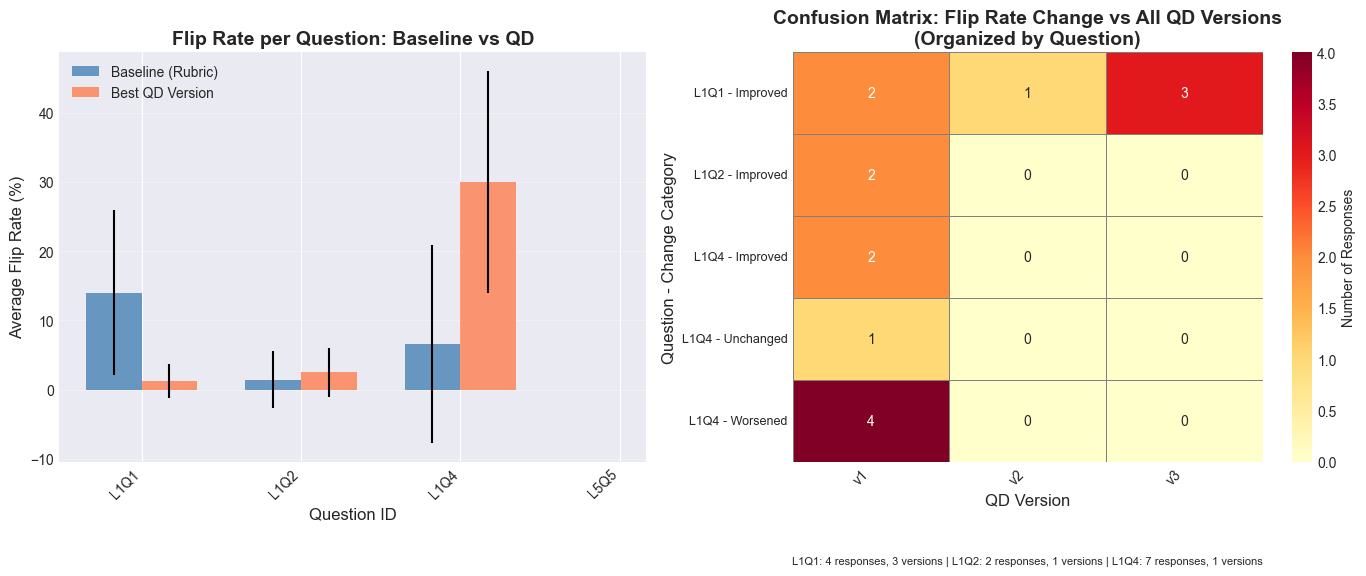


Flip Rate Summary by Question:
question_id  baseline_mean  baseline_std  n_responses  qd_mean  qd_std
       L1Q1          14.00         11.94            5     1.25    2.50
       L1Q2           1.43          4.13           14     2.50    3.54
       L1Q4           6.61         14.34           28    30.00   16.07
       L5Q5           0.00           NaN            1      NaN     NaN

Overall Average:
  Baseline: 5.73% ± 12.20%
  Best QD:  16.92% ± 18.66%
  Average Improvement: 4.23%

GRAPH 2: MAJORITY STABILITY


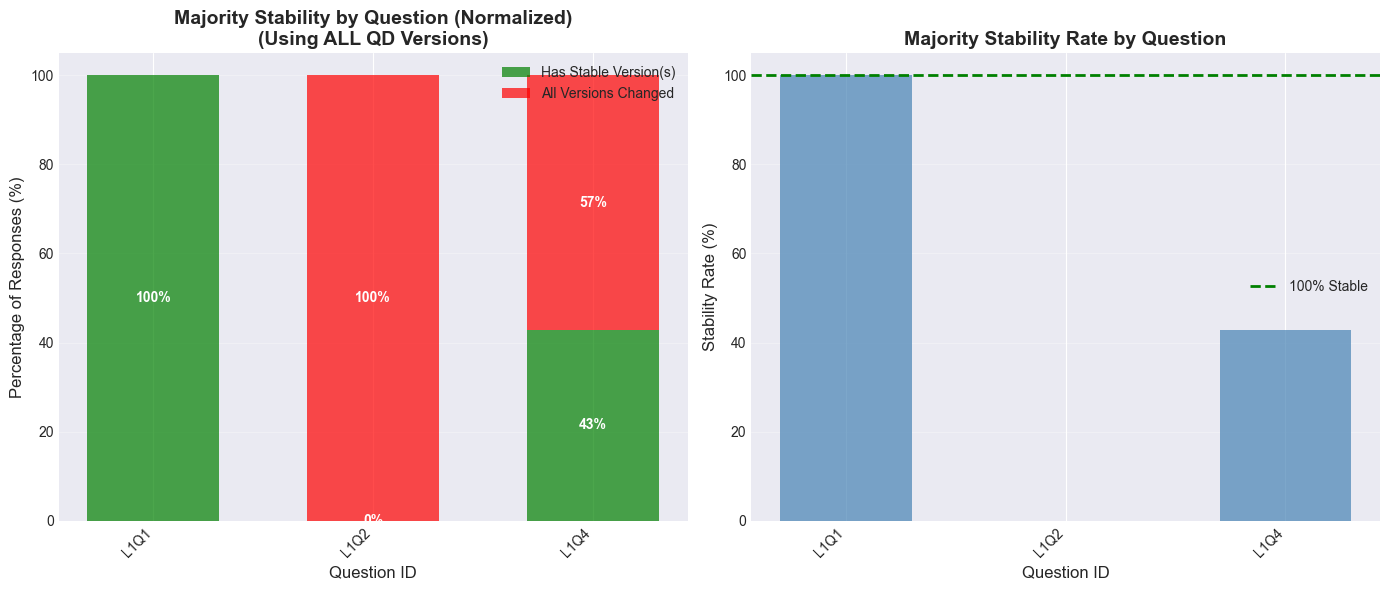


Majority Stability Summary (Using ALL QD Versions):
question_id  stable_responses  unstable_responses  total_responses  total_stable_versions  total_changed_versions  stability_rate
       L1Q1                 4                   0                4                      4                       2        1.000000
       L1Q2                 0                   2                2                      0                       2        0.000000
       L1Q4                 3                   4                7                      3                       4        0.428571

Overall Summary:
  Responses with at least one stable version: 7/13 (53.8%)
  Total QD versions tested: 15
  Stable versions: 7 (46.7%)
  Changed versions: 8 (53.3%)

GRAPH 3: CONSENSUS CHANGES DISTRIBUTION


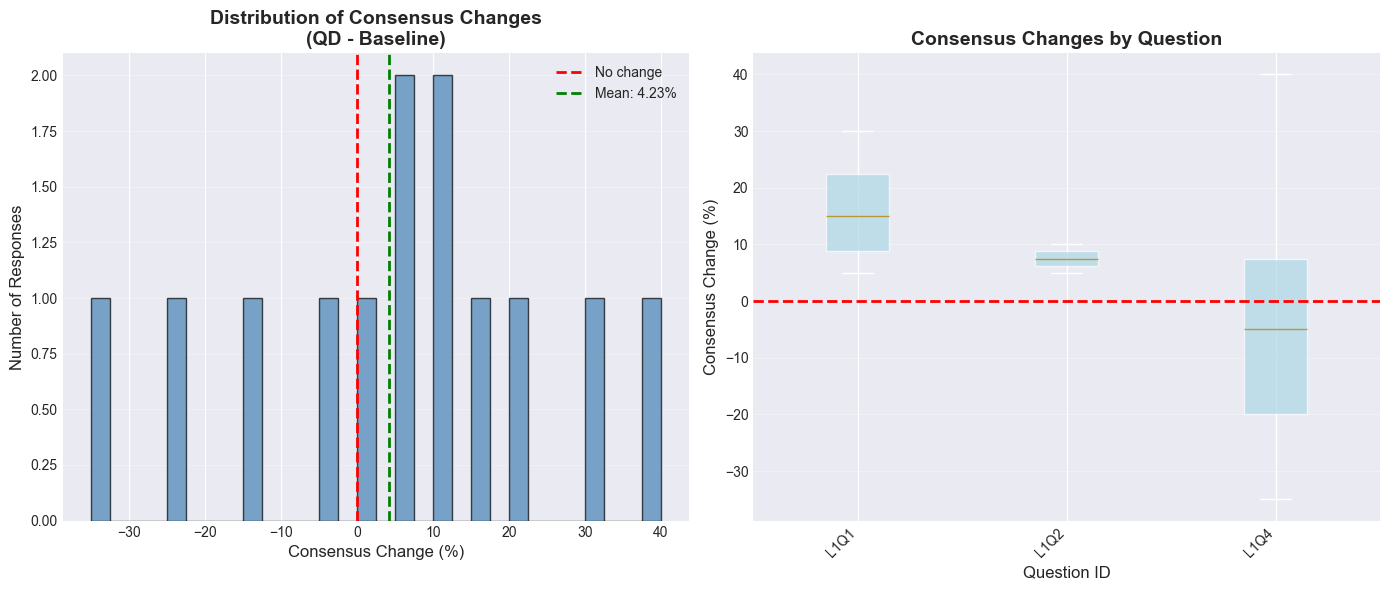


Consensus Changes Summary:
Mean change: 4.23%
Median change: 5.00%
Std deviation: 20.90%
Responses with improved consensus: 8/13 (61.5%)

GRAPH 4: CONSENSUS STRENGTH CHANGES


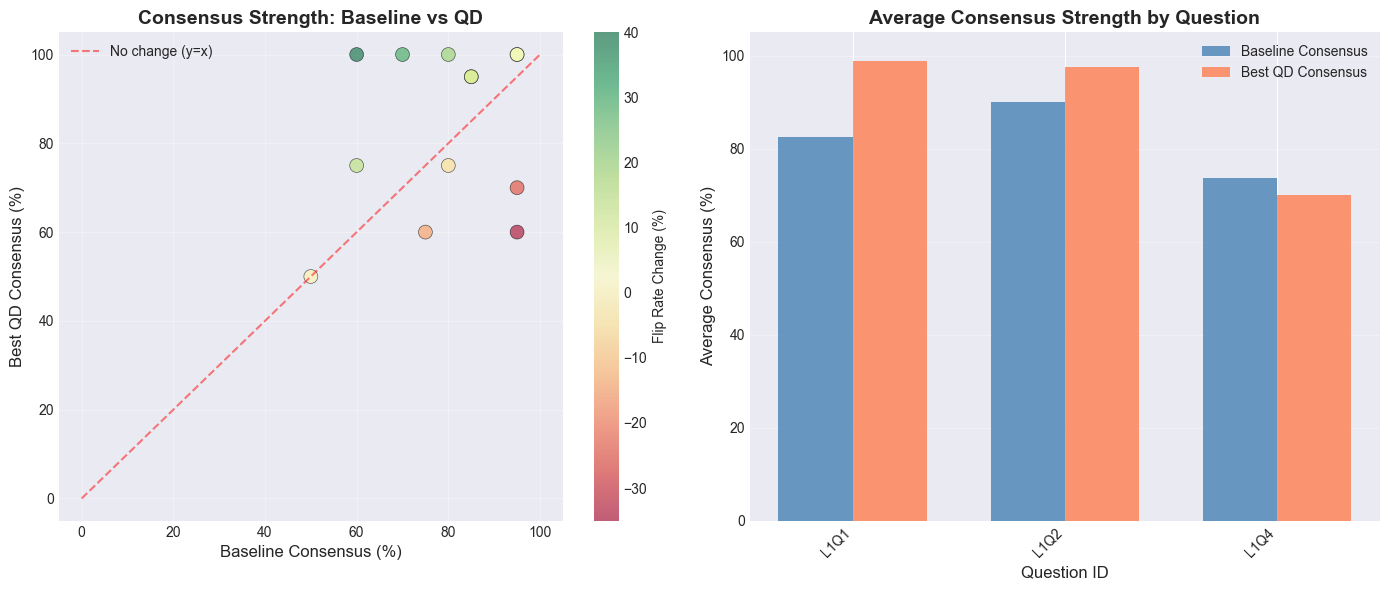


Consensus Strength Summary:
Baseline average consensus: 78.85%
Best QD average consensus: 83.08%
Average consensus improvement: 4.23%

By Question:
question_id  baseline_consensus  best_qd_consensus
       L1Q1           82.500000              98.75
       L1Q2           90.000000              97.50
       L1Q4           73.571429              70.00

GRAPH 5: AVERAGE MAJORITY STRENGTH BY QUESTION


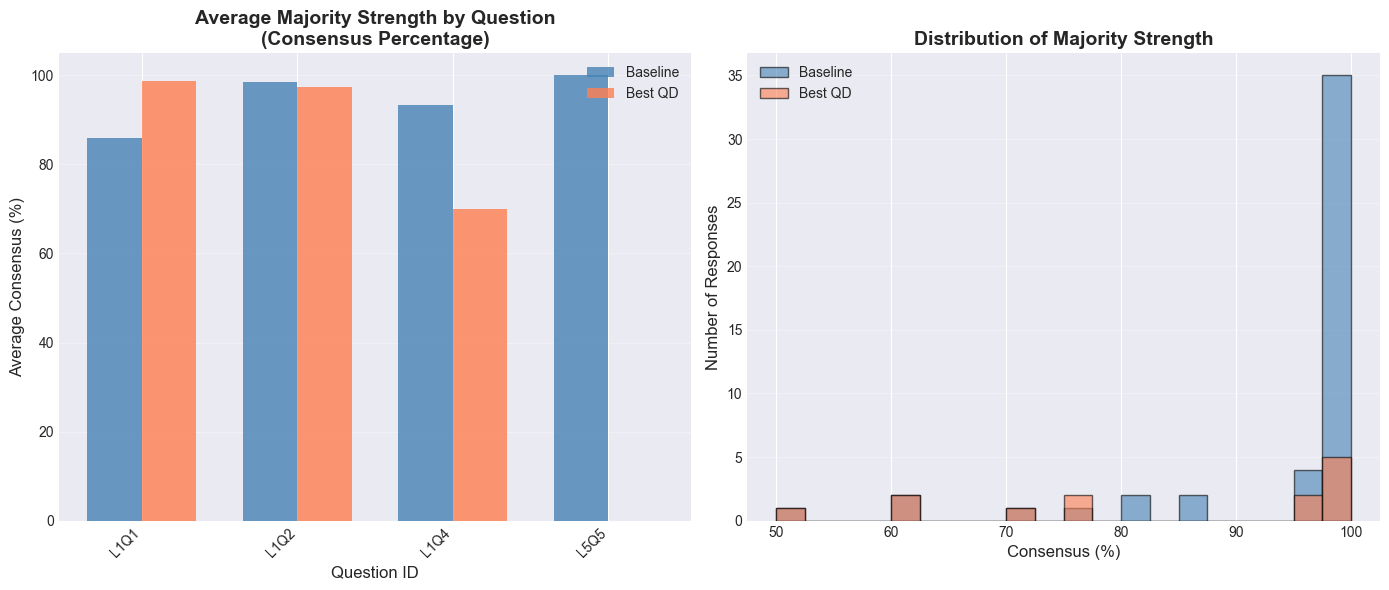


Average Majority Strength (Consensus) by Question:
question_id  baseline_consensus  qd_consensus  improvement
       L1Q1           86.000000         98.75    12.750000
       L1Q2           98.571429         97.50    -1.071429
       L1Q4           93.392857         70.00   -23.392857
       L5Q5          100.000000           NaN          NaN

Overall Average:
  Baseline: 94.27%
  Best QD:  83.08%
  Average Improvement: -3.90%


,question_id,response_id,baseline_flip_rate,baseline_consensus,baseline_majority,baseline_sample_size,qd_initial_flip_rate,qd_initial_consensus,qd_initial_majority,qd_initial_version,...,flip_rate_change,consensus_change,majority_stable,baseline_tie,qd_tie,needs_human_review,skip_reason,qd_versions_majority_stable,qd_versions_majority_changed,total_qd_versions_tested
0,L1Q4,R7,0.0,100.0,1,20,NaN,NaN,NaN,v1,...,NaN,NaN,None,False,False,False,baseline_already_stable,[],[],0
1,L1Q4,R13,5.0,95.0,1,20,30.0,70.0,0.0,v1,...,-25.0,-25.0,False,False,False,False,None,[],[v1],1
2,L1Q2,R14,0.0,100.0,1,20,NaN,NaN,NaN,v1,...,NaN,NaN,None,False,False,False,baseline_already_stable,[],[],0
3,L1Q1,R4,20.0,80.0,1,20,0.0,100.0,0.0,v1,...,20.0,20.0,False,False,False,False,None,[v2],[v1],2
4,L1Q2,R2,0.0,100.0,1,20,NaN,NaN,NaN,v1,...,NaN,NaN,None,False,False,False,baseline_already_stable,[],[],0
5,L1Q1,R11,15.0,85.0,0,20,5.0,95.0,0.0,v3,...,10.0,10.0,True,False,False,False,None,[v3],[],1
6,L1Q4,R25,40.0,60.0,0,20,25.0,75.0,0.0,v1,...,15.0,15.0,True,False,False,False,None,[v1],[],1
7,L1Q4,R24,0.0,100.0,1,20,NaN,NaN,NaN,v1,...,NaN,NaN,None,False,False,False,baseline_already_stable,[],[],0
8,L1Q1,R10,5.0,95.0,1,20,0.0,100.0,1.0,v3,...,5.0,5.0,True,False,False,False,None,[v3],[],1
9,L1Q2,R3,0.0,100.0,1,20,NaN,NaN,NaN,v1,...,NaN,NaN,None,False,False,False,baseline_already_stable,[],[],0


In [187]:
run_all_paper_analysis()

In [191]:
"""
Research Paper Visualizations for LLM Grading Stochasticity Analysis
=====================================================================

This script generates all visualizations for the research paper analyzing:
1. Stochasticity in LLM grading (baseline/rubric-based)
2. QD-based approaches to reduce grading variance

Graphs generated:
1. Flip rate per question (baseline vs QD)
2. Majority stability analysis for all questions
3. Distribution of consensus changes
4. Consensus strength changes
5. Average majority strength by question
6. Normalized outcomes analysis
"""

import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple
from collections import defaultdict
import pandas as pd

# Set publication-quality style
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

class GradingAnalysis:
    """Main analysis class for grading consistency research"""
    
    def __init__(self, checkpoint_dir: str = './checkpoints'):
        self.checkpoint_dir = Path(checkpoint_dir)
        self.data = self._load_all_checkpoints()
        self.questions = self._extract_questions()
        
    def _load_all_checkpoints(self) -> Dict:
        """Load all checkpoint files"""
        data = {}
        for file in self.checkpoint_dir.glob('*.json'):
            try:
                with open(file) as f:
                    key = file.stem  # e.g., "L1Q1_R1"
                    data[key] = json.load(f)
            except Exception as e:
                print(f"Error loading {file}: {e}")
        return data
    
    def _extract_questions(self) -> List[str]:
        """Extract unique question IDs"""
        questions = set()
        for key in self.data.keys():
            # Extract question ID (e.g., "L1Q1" from "L1Q1_R1")
            qid = '_'.join(key.split('_')[:-1])
            questions.add(qid)
        return sorted(questions)
    
    def _get_responses_for_question(self, qid: str) -> List[str]:
        """Get all response IDs for a given question"""
        return [key for key in self.data.keys() if key.startswith(qid + '_')]
    
    def _calculate_flip_rate(self, iterations: List[Dict]) -> float:
        """Calculate flip rate from iterations"""
        if not iterations:
            return 0.0
        
        grades = [it['grade'] for it in iterations if 'grade' in it]
        if len(grades) < 2:
            return 0.0
        
        # Check if there's disagreement
        unique_grades = set(grades)
        if len(unique_grades) > 1:
            return 100.0  # Has flip
        return 0.0  # No flip
    
    def _calculate_consensus(self, iterations: List[Dict]) -> float:
        """Calculate consensus percentage"""
        if not iterations:
            return 0.0
        
        grades = [it['grade'] for it in iterations if 'grade' in it]
        if not grades:
            return 0.0
        
        pass_count = sum(grades)
        fail_count = len(grades) - pass_count
        majority_count = max(pass_count, fail_count)
        
        return (majority_count / len(grades)) * 100
    
    def _calculate_majority_vote(self, iterations: List[Dict]) -> int:
        """Calculate majority vote (0 or 1)"""
        if not iterations:
            return -1
        
        grades = [it['grade'] for it in iterations if 'grade' in it]
        if not grades:
            return -1
        
        pass_count = sum(grades)
        fail_count = len(grades) - pass_count
        
        return 1 if pass_count > fail_count else 0


    # ========================================================================
    # GRAPH 1: Flip Rate Per Question (Baseline vs QD)
    # ========================================================================
    
    def plot_flip_rate_by_question(self, save_path: str = 'flip_rate_by_question.png'):
        """
        Plot flip rate for each question comparing baseline vs QD grading.
        
        Key insight: Shows reduction in grade disagreement with QD approach.
        """
        results = []
        
        for qid in self.questions:
            responses = self._get_responses_for_question(qid)
            
            baseline_flips = 0
            qd_flips = 0
            total_responses = 0
            
            for rid in responses:
                checkpoint = self.data[rid]
                
                # Baseline flip rate
                baseline_iterations = checkpoint.get('baseline_iterations', [])
                if baseline_iterations:
                    total_responses += 1
                    baseline_flip = self._calculate_flip_rate(baseline_iterations)
                    if baseline_flip > 0:
                        baseline_flips += 1
                
                # QD flip rate (use refined if available, otherwise initial)
                qd_iterations = checkpoint.get('qd_refined_iterations', 
                                              checkpoint.get('qd_initial_iterations', []))
                if qd_iterations:
                    qd_flip = self._calculate_flip_rate(qd_iterations)
                    if qd_flip > 0:
                        qd_flips += 1
            
            if total_responses > 0:
                baseline_flip_rate = (baseline_flips / total_responses) * 100
                qd_flip_rate = (qd_flips / total_responses) * 100
                
                results.append({
                    'question': qid,
                    'baseline': baseline_flip_rate,
                    'qd': qd_flip_rate,
                    'n_responses': total_responses
                })
        
        df = pd.DataFrame(results)
        
        # Create plot
        fig, ax = plt.subplots(figsize=(12, 6))
        
        x = np.arange(len(df))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, df['baseline'], width, label='Baseline (Rubric)',
                       color='#e74c3c', alpha=0.8)
        bars2 = ax.bar(x + width/2, df['qd'], width, label='QD-Based',
                       color='#3498db', alpha=0.8)
        
        ax.set_xlabel('Question ID', fontweight='bold')
        ax.set_ylabel('Flip Rate (%)', fontweight='bold')
        ax.set_title('Grade Disagreement: Baseline vs QD-Based Grading', 
                     fontweight='bold', pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(df['question'], rotation=45, ha='right')
        ax.legend(frameon=True, shadow=True)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}%',
                           ha='center', va='bottom', fontsize=8)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.close()
        
        return df


    # ========================================================================
    # GRAPH 2: Majority Stability Analysis
    # ========================================================================
    
    def plot_majority_stability(self, save_path: str = 'majority_stability.png'):
        """
        Plot majority vote stability: how often does majority vote flip
        between baseline and QD approaches?
        
        Categories:
        - Stable Pass: Majority pass in both
        - Stable Fail: Majority fail in both
        - Flip to Pass: Majority changed from fail to pass
        - Flip to Fail: Majority changed from pass to fail
        """
        results = []
        
        for qid in self.questions:
            responses = self._get_responses_for_question(qid)
            
            stable_pass = 0
            stable_fail = 0
            flip_to_pass = 0
            flip_to_fail = 0
            total = 0
            
            for rid in responses:
                checkpoint = self.data[rid]
                
                baseline_iterations = checkpoint.get('baseline_iterations', [])
                qd_iterations = checkpoint.get('qd_refined_iterations',
                                              checkpoint.get('qd_initial_iterations', []))
                
                if baseline_iterations and qd_iterations:
                    baseline_majority = self._calculate_majority_vote(baseline_iterations)
                    qd_majority = self._calculate_majority_vote(qd_iterations)
                    
                    if baseline_majority >= 0 and qd_majority >= 0:
                        total += 1
                        
                        if baseline_majority == 1 and qd_majority == 1:
                            stable_pass += 1
                        elif baseline_majority == 0 and qd_majority == 0:
                            stable_fail += 1
                        elif baseline_majority == 0 and qd_majority == 1:
                            flip_to_pass += 1
                        elif baseline_majority == 1 and qd_majority == 0:
                            flip_to_fail += 1
            
            if total > 0:
                results.append({
                    'question': qid,
                    'stable_pass': (stable_pass / total) * 100,
                    'stable_fail': (stable_fail / total) * 100,
                    'flip_to_pass': (flip_to_pass / total) * 100,
                    'flip_to_fail': (flip_to_fail / total) * 100,
                    'n_responses': total
                })
        
        df = pd.DataFrame(results)
        
        # Create stacked bar chart
        fig, ax = plt.subplots(figsize=(14, 7))
        
        x = np.arange(len(df))
        width = 0.6
        
        p1 = ax.bar(x, df['stable_pass'], width, label='Stable Pass',
                   color='#27ae60', alpha=0.8)
        p2 = ax.bar(x, df['stable_fail'], width, bottom=df['stable_pass'],
                   label='Stable Fail', color='#e74c3c', alpha=0.8)
        p3 = ax.bar(x, df['flip_to_pass'], width,
                   bottom=df['stable_pass'] + df['stable_fail'],
                   label='Flip to Pass', color='#95a5a6', alpha=0.8)
        p4 = ax.bar(x, df['flip_to_fail'], width,
                   bottom=df['stable_pass'] + df['stable_fail'] + df['flip_to_pass'],
                   label='Flip to Fail', color='#34495e', alpha=0.8)
        
        ax.set_xlabel('Question ID', fontweight='bold')
        ax.set_ylabel('Percentage of Responses (%)', fontweight='bold')
        ax.set_title('Majority Vote Stability: Baseline → QD-Based', 
                     fontweight='bold', pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(df['question'], rotation=45, ha='right')
        ax.legend(loc='upper right', frameon=True, shadow=True)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 105)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.close()
        
        return df


    # ========================================================================
    # GRAPH 3: Distribution of Consensus Changes
    # ========================================================================
    
    def plot_consensus_distribution(self, save_path: str = 'consensus_distribution.png'):
        """
        Plot distribution of consensus changes from baseline to QD.
        
        Shows histogram of consensus improvement/degradation.
        """
        consensus_changes = []
        
        for qid in self.questions:
            responses = self._get_responses_for_question(qid)
            
            for rid in responses:
                checkpoint = self.data[rid]
                
                baseline_iterations = checkpoint.get('baseline_iterations', [])
                qd_iterations = checkpoint.get('qd_refined_iterations',
                                              checkpoint.get('qd_initial_iterations', []))
                
                if baseline_iterations and qd_iterations:
                    baseline_consensus = self._calculate_consensus(baseline_iterations)
                    qd_consensus = self._calculate_consensus(qd_iterations)
                    
                    # Consensus change: positive = improvement
                    change = qd_consensus - baseline_consensus
                    consensus_changes.append({
                        'question': qid,
                        'response': rid,
                        'change': change,
                        'baseline_consensus': baseline_consensus,
                        'qd_consensus': qd_consensus
                    })
        
        df = pd.DataFrame(consensus_changes)
        
        # Create histogram
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        
        # Histogram of changes
        ax1.hist(df['change'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
        ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
        ax1.axvline(x=df['change'].mean(), color='green', linestyle='--', 
                   linewidth=2, label=f'Mean: {df["change"].mean():.1f}%')
        ax1.set_xlabel('Consensus Change (QD - Baseline) (%)', fontweight='bold')
        ax1.set_ylabel('Frequency', fontweight='bold')
        ax1.set_title('Distribution of Consensus Changes', fontweight='bold', pad=15)
        ax1.legend(frameon=True, shadow=True)
        ax1.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Scatter plot: baseline vs QD consensus
        ax2.scatter(df['baseline_consensus'], df['qd_consensus'], 
                   alpha=0.5, s=50, color='#9b59b6')
        ax2.plot([0, 100], [0, 100], 'r--', linewidth=2, label='No Change Line')
        ax2.set_xlabel('Baseline Consensus (%)', fontweight='bold')
        ax2.set_ylabel('QD Consensus (%)', fontweight='bold')
        ax2.set_title('Baseline vs QD Consensus', fontweight='bold', pad=15)
        ax2.legend(frameon=True, shadow=True)
        ax2.grid(alpha=0.3, linestyle='--')
        ax2.set_xlim(0, 105)
        ax2.set_ylim(0, 105)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.close()
        
        return df


    # ========================================================================
    # GRAPH 4: Consensus Strength Changes
    # ========================================================================
    
    def plot_consensus_strength_changes(self, save_path: str = 'consensus_strength_changes.png'):
        """
        Plot changes in consensus strength by question.
        
        Shows mean consensus for baseline vs QD for each question.
        """
        results = []
        
        for qid in self.questions:
            responses = self._get_responses_for_question(qid)
            
            baseline_consensuses = []
            qd_consensuses = []
            
            for rid in responses:
                checkpoint = self.data[rid]
                
                baseline_iterations = checkpoint.get('baseline_iterations', [])
                qd_iterations = checkpoint.get('qd_refined_iterations',
                                              checkpoint.get('qd_initial_iterations', []))
                
                if baseline_iterations:
                    baseline_consensuses.append(
                        self._calculate_consensus(baseline_iterations))
                
                if qd_iterations:
                    qd_consensuses.append(
                        self._calculate_consensus(qd_iterations))
            
            if baseline_consensuses and qd_consensuses:
                results.append({
                    'question': qid,
                    'baseline_mean': np.mean(baseline_consensuses),
                    'baseline_std': np.std(baseline_consensuses),
                    'qd_mean': np.mean(qd_consensuses),
                    'qd_std': np.std(qd_consensuses),
                    'improvement': np.mean(qd_consensuses) - np.mean(baseline_consensuses),
                    'n_responses': len(baseline_consensuses)
                })
        
        df = pd.DataFrame(results)
        
        # Create plot with error bars
        fig, ax = plt.subplots(figsize=(14, 7))
        
        x = np.arange(len(df))
        width = 0.35
        
        # Plot with error bars
        ax.errorbar(x - width/2, df['baseline_mean'], yerr=df['baseline_std'],
                   fmt='o', capsize=5, capthick=2, markersize=8,
                   label='Baseline', color='#e74c3c', linewidth=2)
        ax.errorbar(x + width/2, df['qd_mean'], yerr=df['qd_std'],
                   fmt='s', capsize=5, capthick=2, markersize=8,
                   label='QD-Based', color='#3498db', linewidth=2)
        
        # Connect with lines to show improvement
        for i in range(len(df)):
            color = 'green' if df.iloc[i]['improvement'] > 0 else 'red'
            alpha = 0.3
            ax.plot([i - width/2, i + width/2],
                   [df.iloc[i]['baseline_mean'], df.iloc[i]['qd_mean']],
                   color=color, alpha=alpha, linewidth=1.5)
        
        ax.set_xlabel('Question ID', fontweight='bold')
        ax.set_ylabel('Mean Consensus (%) ± Std Dev', fontweight='bold')
        ax.set_title('Consensus Strength: Baseline vs QD-Based', 
                     fontweight='bold', pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(df['question'], rotation=45, ha='right')
        ax.legend(frameon=True, shadow=True)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(0, 105)
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.close()
        
        return df


    # ========================================================================
    # GRAPH 5: Average Majority Strength by Question
    # ========================================================================
    
    def plot_majority_strength(self, save_path: str = 'majority_strength.png'):
        """
        Plot average majority strength (how strong is the consensus in
        the majority direction) for each question.
        
        Majority strength = percentage of votes for the majority decision.
        """
        results = []
        
        for qid in self.questions:
            responses = self._get_responses_for_question(qid)
            
            baseline_strengths = []
            qd_strengths = []
            
            for rid in responses:
                checkpoint = self.data[rid]
                
                baseline_iterations = checkpoint.get('baseline_iterations', [])
                qd_iterations = checkpoint.get('qd_refined_iterations',
                                              checkpoint.get('qd_initial_iterations', []))
                
                if baseline_iterations:
                    grades = [it['grade'] for it in baseline_iterations if 'grade' in it]
                    if grades:
                        pass_rate = sum(grades) / len(grades)
                        # Majority strength is the max of pass_rate and fail_rate
                        majority_strength = max(pass_rate, 1 - pass_rate) * 100
                        baseline_strengths.append(majority_strength)
                
                if qd_iterations:
                    grades = [it['grade'] for it in qd_iterations if 'grade' in it]
                    if grades:
                        pass_rate = sum(grades) / len(grades)
                        majority_strength = max(pass_rate, 1 - pass_rate) * 100
                        qd_strengths.append(majority_strength)
            
            if baseline_strengths and qd_strengths:
                results.append({
                    'question': qid,
                    'baseline': np.mean(baseline_strengths),
                    'qd': np.mean(qd_strengths),
                    'improvement': np.mean(qd_strengths) - np.mean(baseline_strengths),
                    'n_responses': len(baseline_strengths)
                })
        
        df = pd.DataFrame(results)
        
        # Create plot
        fig, ax = plt.subplots(figsize=(14, 7))
        
        x = np.arange(len(df))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, df['baseline'], width, label='Baseline',
                       color='#e74c3c', alpha=0.8)
        bars2 = ax.bar(x + width/2, df['qd'], width, label='QD-Based',
                       color='#3498db', alpha=0.8)
        
        ax.set_xlabel('Question ID', fontweight='bold')
        ax.set_ylabel('Average Majority Strength (%)', fontweight='bold')
        ax.set_title('Majority Strength by Question: Baseline vs QD-Based', 
                     fontweight='bold', pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(df['question'], rotation=45, ha='right')
        ax.legend(frameon=True, shadow=True)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.set_ylim(50, 105)  # Start at 50% since majority is by definition >= 50%
        
        # Add improvement annotations
        for i, row in df.iterrows():
            if abs(row['improvement']) > 1:  # Only annotate significant changes
                color = 'green' if row['improvement'] > 0 else 'red'
                ax.annotate(f'{row["improvement"]:+.1f}',
                           xy=(i, max(row['baseline'], row['qd']) + 2),
                           ha='center', fontsize=8, color=color, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.close()
        
        return df


    # ========================================================================
    # GRAPH 6: Normalized Outcomes Analysis
    # ========================================================================
    
    def plot_normalized_outcomes(self, save_path: str = 'normalized_outcomes.png'):
        """
        Plot normalized grading outcomes per unique response text.
        
        This accounts for the fact that the same response text may appear
        multiple times in the dataset (from different students).
        
        Shows:
        - Pass rate by unique response
        - Grade disagreement rate by unique response
        """
        # Group by unique response texts
        response_groups = defaultdict(lambda: {
            'baseline_grades': [],
            'qd_grades': [],
            'question': None
        })
        
        for rid, checkpoint in self.data.items():
            response_text = checkpoint.get('response_text', '')
            qid = checkpoint.get('question_id', '')
            
            # Get all grades for this response
            baseline_iterations = checkpoint.get('baseline_iterations', [])
            qd_iterations = checkpoint.get('qd_refined_iterations',
                                          checkpoint.get('qd_initial_iterations', []))
            
            if baseline_iterations:
                baseline_grades = [it['grade'] for it in baseline_iterations if 'grade' in it]
                response_groups[response_text]['baseline_grades'].extend(baseline_grades)
                response_groups[response_text]['question'] = qid
            
            if qd_iterations:
                qd_grades = [it['grade'] for it in qd_iterations if 'grade' in it]
                response_groups[response_text]['qd_grades'].extend(qd_grades)
        
        # Calculate metrics per unique response
        results = []
        for response_text, data in response_groups.items():
            if data['baseline_grades'] and data['qd_grades']:
                baseline_grades = data['baseline_grades']
                qd_grades = data['qd_grades']
                
                # Pass rates
                baseline_pass_rate = sum(baseline_grades) / len(baseline_grades)
                qd_pass_rate = sum(qd_grades) / len(qd_grades)
                
                # Disagreement (has any flip)
                baseline_has_disagreement = len(set(baseline_grades)) > 1
                qd_has_disagreement = len(set(qd_grades)) > 1
                
                results.append({
                    'question': data['question'],
                    'baseline_pass_rate': baseline_pass_rate * 100,
                    'qd_pass_rate': qd_pass_rate * 100,
                    'baseline_disagreement': 100 if baseline_has_disagreement else 0,
                    'qd_disagreement': 100 if qd_has_disagreement else 0,
                    'n_baseline_grades': len(baseline_grades),
                    'n_qd_grades': len(qd_grades)
                })
        
        df = pd.DataFrame(results)
        
        # Create figure with 2 subplots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Plot 1: Pass Rate Distribution
        ax1.scatter(df['baseline_pass_rate'], df['qd_pass_rate'], 
                   alpha=0.6, s=80, c=df['question'].astype('category').cat.codes,
                   cmap='tab10', edgecolors='black', linewidth=0.5)
        ax1.plot([0, 100], [0, 100], 'r--', linewidth=2, label='No Change')
        ax1.set_xlabel('Baseline Pass Rate (%)  ', fontweight='bold')
        ax1.set_ylabel('QD Pass Rate (%)', fontweight='bold')
        ax1.set_title('Pass Rate: Baseline vs QD-Based\n(Per Unique Response)', 
                     fontweight='bold', pad=15)
        ax1.legend(frameon=True, shadow=True)
        ax1.grid(alpha=0.3, linestyle='--')
        ax1.set_xlim(-5, 105)
        ax1.set_ylim(-5, 105)
        
        # Plot 2: Disagreement Rate
        disagreement_summary = df.groupby('question').agg({
            'baseline_disagreement': 'mean',
            'qd_disagreement': 'mean'
        }).reset_index()
        
        x = np.arange(len(disagreement_summary))
        width = 0.35
        
        bars1 = ax2.bar(x - width/2, disagreement_summary['baseline_disagreement'], 
                       width, label='Baseline', color='#e74c3c', alpha=0.8)
        bars2 = ax2.bar(x + width/2, disagreement_summary['qd_disagreement'], 
                       width, label='QD-Based', color='#3498db', alpha=0.8)
        
        ax2.set_xlabel('Question ID', fontweight='bold')
        ax2.set_ylabel('Grade Disagreement Rate (%)', fontweight='bold')
        ax2.set_title('Grade Disagreement by Unique Response', 
                     fontweight='bold', pad=15)
        ax2.set_xticks(x)
        ax2.set_xticklabels(disagreement_summary['question'], rotation=45, ha='right')
        ax2.legend(frameon=True, shadow=True)
        ax2.grid(axis='y', alpha=0.3, linestyle='--')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved: {save_path}")
        plt.close()
        
        return df


    # ========================================================================
    # MASTER FUNCTION: Generate All Graphs
    # ========================================================================
    
    def generate_all_graphs(self, output_dir: str = './paper_figures'):
        """Generate all graphs for the research paper"""
        output_path = Path(output_dir)
        output_path.mkdir(exist_ok=True)
        
        print("\n" + "="*80)
        print("GENERATING ALL RESEARCH PAPER VISUALIZATIONS")
        print("="*80 + "\n")
        
        graphs = [
            ("1. Flip Rate by Question", self.plot_flip_rate_by_question,
             str(output_path / "1_flip_rate_by_question.png")),
            ("2. Majority Stability", self.plot_majority_stability,
             str(output_path / "2_majority_stability.png")),
            ("3. Consensus Distribution", self.plot_consensus_distribution,
             str(output_path / "3_consensus_distribution.png")),
            ("4. Consensus Strength Changes", self.plot_consensus_strength_changes,
             str(output_path / "4_consensus_strength_changes.png")),
            ("5. Majority Strength", self.plot_majority_strength,
             str(output_path / "5_majority_strength.png")),
            ("6. Normalized Outcomes", self.plot_normalized_outcomes,
             str(output_path / "6_normalized_outcomes.png"))
        ]
        
        results = {}
        for name, func, save_path in graphs:
            print(f"\nGenerating {name}...")
            try:
                df = func(save_path)
                results[name] = df
                print(f"✓ Success: {save_path}")
            except Exception as e:
                print(f"✗ Error: {e}")
                import traceback
                traceback.print_exc()
        
        print("\n" + "="*80)
        print("ALL VISUALIZATIONS COMPLETE")
        print(f"Saved to: {output_path}")
        print("="*80 + "\n")
        
        return results


    # ========================================================================
    # SUMMARY STATISTICS
    # ========================================================================
    
    def print_summary_statistics(self):
        """Print comprehensive summary statistics for the paper"""
        print("\n" + "="*80)
        print("SUMMARY STATISTICS FOR RESEARCH PAPER")
        print("="*80 + "\n")
        
        total_responses = len(self.data)
        total_questions = len(self.questions)
        
        print(f"Dataset Overview:")
        print(f"  Total responses analyzed: {total_responses}")
        print(f"  Total unique questions: {total_questions}")
        print(f"  Average responses per question: {total_responses / total_questions:.1f}")
        
        # Calculate overall metrics
        baseline_flips = 0
        qd_flips = 0
        baseline_consensus_scores = []
        qd_consensus_scores = []
        
        for rid, checkpoint in self.data.items():
            baseline_iterations = checkpoint.get('baseline_iterations', [])
            qd_iterations = checkpoint.get('qd_refined_iterations',
                                          checkpoint.get('qd_initial_iterations', []))
            
            if baseline_iterations:
                flip_rate = self._calculate_flip_rate(baseline_iterations)
                if flip_rate > 0:
                    baseline_flips += 1
                baseline_consensus_scores.append(
                    self._calculate_consensus(baseline_iterations))
            
            if qd_iterations:
                flip_rate = self._calculate_flip_rate(qd_iterations)
                if flip_rate > 0:
                    qd_flips += 1
                qd_consensus_scores.append(
                    self._calculate_consensus(qd_iterations))
        
        print(f"\nOverall Grading Consistency:")
        print(f"  Baseline flip rate: {(baseline_flips / total_responses) * 100:.1f}%")
        print(f"  QD-based flip rate: {(qd_flips / total_responses) * 100:.1f}%")
        print(f"  Improvement: {((baseline_flips - qd_flips) / total_responses) * 100:+.1f} percentage points")
        
        print(f"\nConsensus Strength:")
        print(f"  Baseline mean consensus: {np.mean(baseline_consensus_scores):.1f}%")
        print(f"  QD-based mean consensus: {np.mean(qd_consensus_scores):.1f}%")
        print(f"  Improvement: {np.mean(qd_consensus_scores) - np.mean(baseline_consensus_scores):+.1f} percentage points")
        
        print("\n" + "="*80 + "\n")


def main():
    """Main execution function"""
    # Initialize analyzer
    analyzer = GradingAnalysis(checkpoint_dir='./checkpoints')
    
    # Print summary statistics
    analyzer.print_summary_statistics()
    
    # Generate all graphs
    results = analyzer.generate_all_graphs(output_dir='./paper_figures')
    
    print("\nDone! Check the ./paper_figures directory for all graphs.")


if __name__ == "__main__":
    main()
    


SUMMARY STATISTICS FOR RESEARCH PAPER

Dataset Overview:
  Total responses analyzed: 66
  Total unique questions: 5
  Average responses per question: 13.2

Overall Grading Consistency:
  Baseline flip rate: 21.2%
  QD-based flip rate: 0.0%
  Improvement: +21.2 percentage points

Consensus Strength:
  Baseline mean consensus: 95.2%
  QD-based mean consensus: 100.0%
  Improvement: +4.8 percentage points



GENERATING ALL RESEARCH PAPER VISUALIZATIONS


Generating 1. Flip Rate by Question...
Saved: paper_figures/1_flip_rate_by_question.png
✓ Success: paper_figures/1_flip_rate_by_question.png

Generating 2. Majority Stability...
Saved: paper_figures/2_majority_stability.png
✓ Success: paper_figures/2_majority_stability.png

Generating 3. Consensus Distribution...
Saved: paper_figures/3_consensus_distribution.png
✓ Success: paper_figures/3_consensus_distribution.png

Generating 4. Consensus Strength Changes...
Saved: paper_figures/4_consensus_strength_changes.png
✓ Success: paper_figures/4

In [193]:
def analyze_checkpoint_schemas(checkpoint_dir=None):
    """
    Analyze and print schemas of all checkpoint JSON files.
    Returns unique schema types found.
    
    Args:
        checkpoint_dir: Path to checkpoint directory (default: from refined_grading_pipeline)
    
    Returns:
        dict: Mapping of schema signature to list of checkpoint files with that schema
    """
    from pathlib import Path
    import json
    from collections import defaultdict
    from refined_grading_pipeline import CHECKPOINT_DIR
    
    if checkpoint_dir is None:
        checkpoint_dir = CHECKPOINT_DIR
    
    checkpoint_dir = Path(checkpoint_dir)
    
    # Store schemas and which files have them
    schema_to_files = defaultdict(list)
    all_keys = set()
    
    print("="*80)
    print("CHECKPOINT SCHEMA ANALYSIS")
    print("="*80)
    print(f"Analyzing checkpoints in: {checkpoint_dir}\n")
    
    # Analyze each checkpoint
    for checkpoint_file in sorted(checkpoint_dir.glob('*.json')):
        try:
            checkpoint = json.loads(checkpoint_file.read_text())
            
            # Get all keys (flattened for nested structures)
            def get_keys(obj, prefix=''):
                keys = set()
                if isinstance(obj, dict):
                    for key, value in obj.items():
                        full_key = f"{prefix}.{key}" if prefix else key
                        keys.add(full_key)
                        if isinstance(value, (dict, list)):
                            keys.update(get_keys(value, full_key))
                elif isinstance(obj, list) and len(obj) > 0:
                    # Check first element if it's a dict
                    if isinstance(obj[0], dict):
                        keys.update(get_keys(obj[0], prefix))
                return keys
            
            file_keys = get_keys(checkpoint)
            all_keys.update(file_keys)
            
            # Create schema signature - get structure with types
            def get_schema_signature(obj, prefix='', max_depth=3, current_depth=0):
                """Get schema signature showing keys and their types"""
                if current_depth > max_depth:
                    return "..."
                
                sig = {}
                if isinstance(obj, dict):
                    for key, value in obj.items():
                        full_key = f"{prefix}.{key}" if prefix else key
                        if isinstance(value, dict):
                            sig[full_key] = get_schema_signature(value, full_key, max_depth, current_depth + 1)
                        elif isinstance(value, list):
                            if len(value) > 0:
                                if isinstance(value[0], dict):
                                    # Show structure of first list item
                                    sig[full_key] = f"list[{get_schema_signature(value[0], full_key, max_depth, current_depth + 1)}]"
                                else:
                                    sig[full_key] = f"list[{type(value[0]).__name__}]"
                            else:
                                sig[full_key] = "list[]"
                        else:
                            sig[full_key] = type(value).__name__
                return sig
            
            schema_sig = get_schema_signature(checkpoint)
            
            # Create a hashable signature string for grouping
            def signature_to_string(sig, indent=0):
                """Convert schema dict to readable string"""
                lines = []
                for key in sorted(sig.keys()):
                    value = sig[key]
                    if isinstance(value, dict):
                        lines.append("  " * indent + f"{key}:")
                        sub_lines = signature_to_string(value, indent + 1)
                        if sub_lines:
                            lines.append(sub_lines)
                    else:
                        lines.append("  " * indent + f"{key}: {value}")
                return "\n".join(lines)
            
            sig_string = signature_to_string(schema_sig)
            
            # Also create a simple top-level key signature for grouping
            top_level_keys = tuple(sorted(checkpoint.keys()))
            schema_to_files[sig_string].append({
                'file': checkpoint_file.name,
                'top_level_keys': top_level_keys
            })
            
        except Exception as e:
            print(f"Error analyzing {checkpoint_file.name}: {e}")
            continue
    
    # Print results
    total_files = sum(len(file_info_list) for file_info_list in schema_to_files.values())
    print(f"Total checkpoints analyzed: {total_files}")
    print(f"Unique schema types: {len(schema_to_files)}\n")
    
    print("="*80)
    print("UNIQUE SCHEMA TYPES")
    print("="*80)
    
    for i, (schema_sig, file_info_list) in enumerate(schema_to_files.items(), 1):
        print(f"\n{'='*80}")
        print(f"SCHEMA TYPE {i} ({len(file_info_list)} files)")
        print(f"{'='*80}")
        print(f"Files with this schema:")
        for file_info in sorted(file_info_list, key=lambda x: x['file']):
            if isinstance(file_info, dict):
                print(f"  - {file_info['file']}")
                print(f"    Top-level keys: {', '.join(file_info['top_level_keys'])}")
            else:
                # Backward compatibility
                print(f"  - {file_info}")
        print(f"\nSchema structure:")
        print(schema_sig)
        print()
    
    # Print all unique keys found across all checkpoints
    print("="*80)
    print("ALL UNIQUE KEYS FOUND (across all checkpoints)")
    print("="*80)
    for key in sorted(all_keys):
        print(f"  - {key}")
    
    # Also group by top-level keys for simpler overview
    print("\n" + "="*80)
    print("GROUPED BY TOP-LEVEL KEYS")
    print("="*80)
    top_level_groups = defaultdict(list)
    for schema_sig, file_info_list in schema_to_files.items():
        # Get unique top-level key sets
        for file_info in file_info_list:
            if isinstance(file_info, dict):
                key_tuple = file_info['top_level_keys']
                top_level_groups[key_tuple].append(file_info['file'])
    
    for i, (keys, files) in enumerate(sorted(top_level_groups.items(), key=lambda x: len(x[1]), reverse=True), 1):
        print(f"\nGroup {i}: {len(files)} files")
        print(f"  Top-level keys: {', '.join(keys)}")
        print(f"  Files: {', '.join(sorted(files)[:10])}")
        if len(files) > 10:
            print(f"  ... and {len(files) - 10} more")
    
    return schema_to_files


In [ ]:
# Analyze all checkpoints
schemas = analyze_checkpoint_schemas()

# Or specify a custom directory
schemas = analyze_checkpoint_schemas(checkpoint_dir='./checkpoints')

In [200]:
"""
Complete Analysis Suite - All Requested Metrics
================================================

Includes:
1. Majority stability for all questions (including flips)
2. Distribution of consensus changes
3. Consensus strength changes
4. Average majority strength by question
5. Normalized outcomes analysis

Key distinction:
- Flip rate: Grade disagreement within iterations (stochasticity)
- Majority flip: Change in final decision between baseline and QD (outcome change)
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple

# Clean style
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#CCCCCC'
})

class ComprehensiveGradingAnalysis:
    """Complete analysis with all requested metrics"""
    
    def __init__(self, checkpoint_dir: str):
        self.checkpoint_dir = Path(checkpoint_dir)
        self.data = self._load_all_checkpoints()
        self.per_response_metrics = self._calculate_all_metrics()
        
    def _load_all_checkpoints(self):
        """Load all checkpoint files"""
        data = {}
        for file in self.checkpoint_dir.glob('*.json'):
            if file.name == 'questions.json':
                continue
            try:
                with open(file) as f:
                    data[file.stem] = json.load(f)
            except Exception as e:
                print(f"Error loading {file}: {e}")
        return data
    
    def _calculate_baseline_metrics(self, iterations: List[Dict]) -> Dict:
        """Calculate metrics from iterations"""
        if not iterations:
            return None
        
        grades = [it['grade'] for it in iterations if 'grade' in it]
        if not grades:
            return None
        
        # Flip rate (stochasticity)
        has_flip = len(set(grades)) > 1
        flip_rate = 100.0 if has_flip else 0.0
        
        # Consensus
        pass_count = sum(grades)
        fail_count = len(grades) - pass_count
        majority_count = max(pass_count, fail_count)
        consensus = (majority_count / len(grades)) * 100
        
        # Majority vote (final decision)
        majority = 1 if pass_count > fail_count else 0
        
        # Majority strength (how strong is the majority)
        majority_strength = (majority_count / len(grades)) * 100
        
        return {
            'grades': grades,
            'flip_rate': flip_rate,
            'consensus': consensus,
            'majority': majority,
            'majority_strength': majority_strength,
            'pass_count': pass_count,
            'fail_count': fail_count,
            'total_count': len(grades)
        }
    
    def _find_best_qd_version(self, checkpoint: Dict, baseline_metrics: Dict) -> Tuple[Dict, str]:
        """
        Find the best QD version (lowest flip rate, maintaining majority if possible)
        Returns (best_qd_metrics, best_version_name)
        """
        best_metrics = None
        best_version = None
        best_flip_rate = float('inf')
        baseline_majority = baseline_metrics['majority']
        
        # Check initial QD version
        qd_initial_iters = checkpoint.get('qd_initial_iterations', [])
        if qd_initial_iters:
            initial_metrics = self._calculate_baseline_metrics(qd_initial_iters)
            if initial_metrics:
                # Prefer versions that maintain majority, but prioritize lower flip rate
                flip_rate = initial_metrics['flip_rate']
                maintains_majority = (initial_metrics['majority'] == baseline_majority)
                
                # Score: lower flip rate is better, maintaining majority is bonus
                score = flip_rate - (100 if maintains_majority else 0)
                
                if score < best_flip_rate:
                    best_metrics = initial_metrics
                    best_version = checkpoint.get('qd_initial_version', 'v1')
                    best_flip_rate = score
        
        # Check all refined versions
        for key in checkpoint.keys():
            if key.startswith('qd_refined_metrics_'):
                version = key.replace('qd_refined_metrics_', '')
                refined_metrics = checkpoint[key]
                if refined_metrics and isinstance(refined_metrics, dict):
                    flip_rate = refined_metrics.get('flip_rate', 100)
                    maintains_majority = (refined_metrics.get('majority', -1) == baseline_majority)
                    score = flip_rate - (100 if maintains_majority else 0)
                    
                    if score < best_flip_rate:
                        # Recalculate from iterations if available
                        refined_iters = checkpoint.get('qd_refined_iterations', [])
                        if refined_iters:
                            # Filter by version
                            version_iters = [it for it in refined_iters 
                                           if it.get('qd_version') == version]
                            if version_iters:
                                best_metrics = self._calculate_baseline_metrics(version_iters)
                                if best_metrics:
                                    best_version = version
                                    best_flip_rate = score
                        else:
                            # Use stored metrics
                            best_metrics = {
                                'flip_rate': refined_metrics.get('flip_rate', 100),
                                'consensus': refined_metrics.get('consensus', 0),
                                'majority': refined_metrics.get('majority', -1),
                                'majority_strength': refined_metrics.get('consensus', 0),
                                'pass_count': refined_metrics.get('pass_count', 0),
                                'fail_count': refined_metrics.get('fail_count', 0),
                                'total_count': refined_metrics.get('sample_size', 0),
                                'grades': []  # Not available from stored metrics
                            }
                            best_version = version
                            best_flip_rate = score
        
        # Also check main qd_refined_metrics if it exists
        qd_refined_metrics = checkpoint.get('qd_refined_metrics', {})
        qd_refined_version = checkpoint.get('qd_refined_version')
        if qd_refined_metrics and qd_refined_version:
            flip_rate = qd_refined_metrics.get('flip_rate', 100)
            maintains_majority = (qd_refined_metrics.get('majority', -1) == baseline_majority)
            score = flip_rate - (100 if maintains_majority else 0)
            
            if score < best_flip_rate:
                # Try to get from iterations first
                refined_iters = checkpoint.get('qd_refined_iterations', [])
                if refined_iters:
                    version_iters = [it for it in refined_iters 
                                   if it.get('qd_version') == qd_refined_version]
                    if version_iters:
                        best_metrics = self._calculate_baseline_metrics(version_iters)
                        if best_metrics:
                            best_version = qd_refined_version
                            best_flip_rate = score
                else:
                    # Use stored metrics
                    best_metrics = {
                        'flip_rate': qd_refined_metrics.get('flip_rate', 100),
                        'consensus': qd_refined_metrics.get('consensus', 0),
                        'majority': qd_refined_metrics.get('majority', -1),
                        'majority_strength': qd_refined_metrics.get('consensus', 0),
                        'pass_count': qd_refined_metrics.get('pass_count', 0),
                        'fail_count': qd_refined_metrics.get('fail_count', 0),
                        'total_count': qd_refined_metrics.get('sample_size', 0),
                        'grades': []
                    }
                    best_version = qd_refined_version
                    best_flip_rate = score
        
        return best_metrics, best_version
    
    def _calculate_all_metrics(self) -> pd.DataFrame:
        """Calculate comprehensive metrics for each response - PRE-QD vs POST-QD"""
        records = []
        
        for key, checkpoint in self.data.items():
            qid = checkpoint.get('question_id', 'Unknown')
            rid = checkpoint.get('response_id', 'Unknown')
            skip_reason = checkpoint.get('skip_reason', 'processed')
            
            if qid == 'Unknown':
                continue
            
            # PRE-QD: Baseline metrics (RUBRIC)
            baseline_iters = checkpoint.get('baseline_iterations', [])
            baseline_metrics = self._calculate_baseline_metrics(baseline_iters)
            
            if not baseline_metrics:
                continue
            
            # POST-QD: Find best QD version
            if skip_reason == 'baseline_already_stable':
                # Baseline was already perfect, so QD = baseline
                qd_metrics = {
                    'grades': baseline_metrics['grades'],
                    'flip_rate': 0.0,
                    'consensus': 100.0,
                    'majority': baseline_metrics['majority'],
                    'majority_strength': 100.0,
                    'pass_count': baseline_metrics['pass_count'],
                    'fail_count': baseline_metrics['fail_count'],
                    'total_count': baseline_metrics['total_count']
                }
                best_qd_version = 'baseline_stable'
            else:
                qd_metrics, best_qd_version = self._find_best_qd_version(checkpoint, baseline_metrics)
                if not qd_metrics:
                    continue
            
            # Calculate changes
            consensus_change = qd_metrics['consensus'] - baseline_metrics['consensus']
            majority_changed = baseline_metrics['majority'] != qd_metrics['majority']
            
            # Classify majority change
            if majority_changed:
                if baseline_metrics['majority'] == 0 and qd_metrics['majority'] == 1:
                    majority_change_type = 'flip_to_pass'
                else:
                    majority_change_type = 'flip_to_fail'
            else:
                if baseline_metrics['majority'] == 1:
                    majority_change_type = 'stable_pass'
                else:
                    majority_change_type = 'stable_fail'
            
            records.append({
                'question_id': qid,
                'response_id': rid,
                'skip_reason': skip_reason,
                'best_qd_version': best_qd_version,
                
                # PRE-QD (Baseline/Rubric)
                'pre_qd_flip_rate': baseline_metrics['flip_rate'],
                'pre_qd_consensus': baseline_metrics['consensus'],
                'pre_qd_majority': baseline_metrics['majority'],
                'pre_qd_majority_strength': baseline_metrics['majority_strength'],
                'pre_qd_pass_count': baseline_metrics['pass_count'],
                'pre_qd_fail_count': baseline_metrics['fail_count'],
                'pre_qd_sample_size': baseline_metrics['total_count'],
                
                # POST-QD (Best QD Version)
                'post_qd_flip_rate': qd_metrics['flip_rate'],
                'post_qd_consensus': qd_metrics['consensus'],
                'post_qd_majority': qd_metrics['majority'],
                'post_qd_majority_strength': qd_metrics['majority_strength'],
                'post_qd_pass_count': qd_metrics['pass_count'],
                'post_qd_fail_count': qd_metrics['fail_count'],
                'post_qd_sample_size': qd_metrics['total_count'],
                
                # Changes (POST-QD - PRE-QD)
                'consensus_change': consensus_change,
                'majority_changed': majority_changed,
                'majority_change_type': majority_change_type,
                'flip_rate_reduction': baseline_metrics['flip_rate'] - qd_metrics['flip_rate'],
                'majority_strength_change': qd_metrics['majority_strength'] - baseline_metrics['majority_strength'],
                
                # Legacy columns for backward compatibility
                'baseline_flip_rate': baseline_metrics['flip_rate'],
                'baseline_consensus': baseline_metrics['consensus'],
                'baseline_majority': baseline_metrics['majority'],
                'baseline_majority_strength': baseline_metrics['majority_strength'],
                'baseline_pass_count': baseline_metrics['pass_count'],
                'baseline_fail_count': baseline_metrics['fail_count'],
                'qd_flip_rate': qd_metrics['flip_rate'],
                'qd_consensus': qd_metrics['consensus'],
                'qd_majority': qd_metrics['majority'],
                'qd_majority_strength': qd_metrics['majority_strength'],
                'qd_pass_count': qd_metrics['pass_count'],
                'qd_fail_count': qd_metrics['fail_count']
            })
        
        return pd.DataFrame(records)
    
    # ========================================================================
    # METRIC 1: Majority Stability for All Questions
    # ========================================================================
    
    def plot_majority_stability_detailed(self, save_path='1_majority_stability_detailed.png'):
        """
        Detailed majority stability showing:
        - Stable Pass (both PRE-QD and POST-QD pass)
        - Stable Fail (both PRE-QD and POST-QD fail)
        - Flip to Pass (PRE-QD fail → POST-QD pass) ⚠️
        - Flip to Fail (PRE-QD pass → POST-QD fail) ⚠️
        """
        df = self.per_response_metrics
        
        # Calculate percentages by question
        question_stats = []
        for qid in sorted(df['question_id'].unique()):
            qdf = df[df['question_id'] == qid]
            total = len(qdf)
            
            stats = {
                'question': qid,
                'stable_pass': (qdf['majority_change_type'] == 'stable_pass').sum() / total * 100,
                'stable_fail': (qdf['majority_change_type'] == 'stable_fail').sum() / total * 100,
                'flip_to_pass': (qdf['majority_change_type'] == 'flip_to_pass').sum() / total * 100,
                'flip_to_fail': (qdf['majority_change_type'] == 'flip_to_fail').sum() / total * 100,
                'n_responses': total,
                'n_flips': qdf['majority_changed'].sum()
            }
            question_stats.append(stats)
        
        qstats_df = pd.DataFrame(question_stats)
        
        # Create stacked bar chart
        fig, ax = plt.subplots(figsize=(14, 7))
        
        x = np.arange(len(qstats_df))
        width = 0.7
        
        # Stack the bars
        bottom = np.zeros(len(qstats_df))
        colors = {
            'stable_pass': '#27ae60',
            'stable_fail': '#e74c3c',
            'flip_to_pass': '#3498db',
            'flip_to_fail': '#e67e22'
        }
        labels = {
            'stable_pass': 'Stable Pass (✓)',
            'stable_fail': 'Stable Fail (✓)',
            'flip_to_pass': 'Flip to Pass (⚠)',
            'flip_to_fail': 'Flip to Fail (⚠)'
        }
        
        for category, color in colors.items():
            values = qstats_df[category].values
            ax.bar(x, values, width, bottom=bottom, label=labels[category],
                   color=color, alpha=0.85, edgecolor='black', linewidth=1)
            
            # Add percentage labels for non-zero values
            for i, val in enumerate(values):
                if val > 2:  # Only label if > 2%
                    y_pos = bottom[i] + val/2
                    ax.text(i, y_pos, f'{val:.1f}%', ha='center', va='center',
                           fontsize=9, fontweight='bold', color='white')
            
            bottom += values
        
        ax.set_xlabel('Question ID', fontweight='bold', fontsize=13)
        ax.set_ylabel('Percentage of Responses (%)', fontweight='bold', fontsize=13)
        ax.set_title('Majority Vote Stability: PRE-QD (Baseline) → POST-QD (Best QD)\n' +
                     '(Shows final grading outcome changes)', 
                     fontweight='bold', fontsize=14, pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(qstats_df['question'], fontsize=11)
        ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
        ax.set_ylim(0, 105)
        
        # Add sample size and flip count
        for i, row in qstats_df.iterrows():
            label = f"n={int(row['n_responses'])}"
            if row['n_flips'] > 0:
                label += f"\n{int(row['n_flips'])} flips"
            ax.text(i, 102, label, ha='center', fontsize=9, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
        plt.close()
        
        return qstats_df
    
    # ========================================================================
    # METRIC 2: Distribution of Consensus Changes
    # ========================================================================
    
    def plot_consensus_change_distribution(self, save_path='2_consensus_change_distribution.png'):
        """
        Distribution of consensus changes showing:
        - Histogram of individual changes
        - By-question boxplots
        """
        df = self.per_response_metrics
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Plot 1: Histogram of consensus changes
        changes = df['consensus_change'].values
        
        ax1.hist(changes, bins=30, color='#3498db', alpha=0.7, edgecolor='black')
        ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change', zorder=5)
        ax1.axvline(x=changes.mean(), color='green', linestyle='--', linewidth=2,
                   label=f'Mean: {changes.mean():.1f}pp', zorder=5)
        
        ax1.set_xlabel('Consensus Change (POST-QD - PRE-QD) in percentage points', fontweight='bold')
        ax1.set_ylabel('Number of Responses', fontweight='bold')
        ax1.set_title('Distribution of Consensus Changes\n(Positive = Improvement)', 
                     fontweight='bold', pad=15)
        ax1.legend(frameon=True, shadow=True)
        ax1.grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f"""Stats:
Mean: {changes.mean():.1f}pp
Median: {np.median(changes):.1f}pp
Std: {changes.std():.1f}pp
Min: {changes.min():.1f}pp
Max: {changes.max():.1f}pp
Improved: {(changes > 0).sum()}/{len(changes)}"""
        
        ax1.text(0.02, 0.98, stats_text, transform=ax1.transAxes,
                verticalalignment='top', bbox=dict(boxstyle='round', 
                facecolor='wheat', alpha=0.8), fontsize=9, family='monospace')
        
        # Plot 2: Boxplot by question
        question_order = sorted(df['question_id'].unique())
        data_by_question = [df[df['question_id'] == qid]['consensus_change'].values
                           for qid in question_order]
        
        bp = ax2.boxplot(data_by_question, labels=question_order,
                        patch_artist=True, showmeans=True,
                        meanprops=dict(marker='D', markerfacecolor='red', 
                                      markersize=8, markeredgecolor='black', label='Mean'),
                        medianprops=dict(color='blue', linewidth=2))
        
        for patch in bp['boxes']:
            patch.set_facecolor('#3498db')
            patch.set_alpha(0.7)
        
        ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        ax2.set_xlabel('Question ID', fontweight='bold')
        ax2.set_ylabel('Consensus Change (POST-QD - PRE-QD, percentage points)', fontweight='bold')
        ax2.set_title('Consensus Change by Question\n(Boxplot shows distribution)', 
                     fontweight='bold', pad=15)
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add mean values as text
        for i, qid in enumerate(question_order):
            mean_val = df[df['question_id'] == qid]['consensus_change'].mean()
            ax2.text(i+1, ax2.get_ylim()[1] * 0.9, f'{mean_val:+.1f}pp',
                    ha='center', fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
        plt.close()
        
        return df[['question_id', 'consensus_change']]
    
    # ========================================================================
    # METRIC 3: Consensus Strength Changes
    # ========================================================================
    
    def plot_consensus_strength_changes(self, save_path='3_consensus_strength_changes.png'):
        """
        Show consensus strength (mean ± std) for baseline vs QD by question
        """
        df = self.per_response_metrics
        
        # Calculate per-question statistics
        question_stats = []
        for qid in sorted(df['question_id'].unique()):
            qdf = df[df['question_id'] == qid]
            
            question_stats.append({
                'question': qid,
                'pre_qd_mean': qdf['pre_qd_consensus'].mean(),
                'pre_qd_std': qdf['pre_qd_consensus'].std(),
                'post_qd_mean': qdf['post_qd_consensus'].mean(),
                'post_qd_std': qdf['post_qd_consensus'].std(),
                'improvement': qdf['consensus_change'].mean(),
                'n': len(qdf)
            })
        
        qstats_df = pd.DataFrame(question_stats)
        
        fig, ax = plt.subplots(figsize=(14, 7))
        
        x = np.arange(len(qstats_df))
        
        # Plot with error bars
        ax.errorbar(x - 0.2, qstats_df['pre_qd_mean'], yerr=qstats_df['pre_qd_std'],
                   fmt='o', capsize=8, capthick=2.5, markersize=12, linewidth=2.5,
                   label='PRE-QD (Baseline)', color='#e74c3c', ecolor='#e74c3c', 
                   alpha=0.8, markeredgecolor='black', markeredgewidth=1.5)
        ax.errorbar(x + 0.2, qstats_df['post_qd_mean'], yerr=qstats_df['post_qd_std'],
                   fmt='s', capsize=8, capthick=2.5, markersize=12, linewidth=2.5,
                   label='POST-QD (Best QD)', color='#3498db', ecolor='#3498db',
                   alpha=0.8, markeredgecolor='black', markeredgewidth=1.5)
        
        # Connect with lines showing improvement direction
        for i in range(len(qstats_df)):
            improvement = qstats_df.iloc[i]['improvement']
            color = '#27ae60' if improvement > 0 else '#e67e22' if improvement < 0 else 'gray'
            alpha = min(0.8, 0.3 + abs(improvement) / 50)  # More visible for larger changes
            ax.plot([i - 0.2, i + 0.2],
                   [qstats_df.iloc[i]['pre_qd_mean'], qstats_df.iloc[i]['post_qd_mean']],
                   color=color, alpha=alpha, linewidth=3, linestyle='--', zorder=1)
        
        ax.set_xlabel('Question ID', fontweight='bold', fontsize=13)
        ax.set_ylabel('Mean Consensus (%) ± Standard Deviation', fontweight='bold', fontsize=13)
        ax.set_title('Consensus Strength: PRE-QD (Baseline) vs POST-QD (Best QD)\n' +
                     '(Error bars show variability across responses)', 
                     fontweight='bold', fontsize=14, pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(qstats_df['question'], fontsize=11)
        ax.legend(loc='lower right', frameon=True, shadow=True, fontsize=11)
        ax.set_ylim(50, 105)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add improvement annotations
        for i, row in qstats_df.iterrows():
            if abs(row['improvement']) > 0.5:
                color = 'green' if row['improvement'] > 0 else 'red'
                y_pos = max(row['pre_qd_mean'], row['post_qd_mean']) + max(row['pre_qd_std'], row['post_qd_std']) + 2
                ax.annotate(f'{row["improvement"]:+.1f}pp',
                           xy=(i, y_pos), ha='center', fontsize=10,
                           color=color, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                                   edgecolor=color, linewidth=2, alpha=0.9))
        
        # Add sample sizes
        for i, row in qstats_df.iterrows():
            ax.text(i, 52, f"n={int(row['n'])}", ha='center', fontsize=9, 
                   style='italic', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
        plt.close()
        
        return qstats_df
    
    # ========================================================================
    # METRIC 4: Average Majority Strength by Question
    # ========================================================================
    
    def plot_average_majority_strength(self, save_path='4_average_majority_strength.png'):
        """
        Average majority strength (how decisive are the grades) by question
        """
        df = self.per_response_metrics
        
        # Calculate per-question statistics
        question_stats = []
        for qid in sorted(df['question_id'].unique()):
            qdf = df[df['question_id'] == qid]
            
            question_stats.append({
                'question': qid,
                'pre_qd_strength': qdf['pre_qd_majority_strength'].mean(),
                'post_qd_strength': qdf['post_qd_majority_strength'].mean(),
                'improvement': qdf['majority_strength_change'].mean(),
                'n': len(qdf)
            })
        
        qstats_df = pd.DataFrame(question_stats)
        
        fig, ax = plt.subplots(figsize=(14, 7))
        
        x = np.arange(len(qstats_df))
        width = 0.35
        
        bars1 = ax.bar(x - width/2, qstats_df['pre_qd_strength'], width,
                       label='PRE-QD (Baseline)', color='#e74c3c', alpha=0.85, 
                       edgecolor='black', linewidth=1.5)
        bars2 = ax.bar(x + width/2, qstats_df['post_qd_strength'], width,
                       label='POST-QD (Best QD)', color='#3498db', alpha=0.85,
                       edgecolor='black', linewidth=1.5)
        
        ax.set_xlabel('Question ID', fontweight='bold', fontsize=13)
        ax.set_ylabel('Average Majority Strength (%)', fontweight='bold', fontsize=13)
        ax.set_title('Majority Strength by Question: PRE-QD (Baseline) vs POST-QD (Best QD)\n' +
                     '(Higher = more decisive grading)', 
                     fontweight='bold', fontsize=14, pad=20)
        ax.set_xticks(x)
        ax.set_xticklabels(qstats_df['question'], fontsize=11)
        ax.legend(frameon=True, shadow=True, fontsize=11)
        ax.set_ylim(50, 105)
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add 50% reference line (bare majority)
        ax.axhline(y=50, color='gray', linestyle=':', linewidth=2, alpha=0.5, 
                  label='Bare Majority (50%)')
        
        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if height > 51:
                    ax.text(bar.get_x() + bar.get_width()/2., height - 2,
                           f'{height:.1f}%', ha='center', va='top', 
                           fontsize=9, fontweight='bold', color='white')
        
        # Add improvement annotations
        for i, row in qstats_df.iterrows():
            if abs(row['improvement']) > 0.5:
                color = 'green' if row['improvement'] > 0 else 'red'
                y_pos = max(row['pre_qd_strength'], row['post_qd_strength']) + 3
                ax.annotate(f'{row["improvement"]:+.1f}pp',
                           xy=(i, y_pos), ha='center', fontsize=9,
                           color=color, fontweight='bold',
                           bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                   edgecolor=color, alpha=0.8))
        
        # Add sample sizes
        for i, row in qstats_df.iterrows():
            ax.text(i, 52, f"n={int(row['n'])}", ha='center', fontsize=9, 
                   style='italic')
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
        plt.close()
        
        return qstats_df
    
    # ========================================================================
    # METRIC 5: Normalized Outcomes (by unique response text)
    # ========================================================================
    
    def plot_normalized_outcomes(self, save_path='5_normalized_outcomes.png'):
        """
        Normalize by unique response texts to avoid counting duplicates
        Shows: Total Submissions vs Unique Responses, and disagreement rates
        """
        # Group by unique response texts (by question)
        response_groups = defaultdict(lambda: {
            'question_id': None,
            'baseline_grades_all': [],
            'qd_grades_all': [],
            'total_submissions': 0,  # Count of actual checkpoint files
            'unique_responses': set()  # Set of unique response texts
        })
        
        for key, checkpoint in self.data.items():
            qid = checkpoint.get('question_id', 'Unknown')
            if qid == 'Unknown':
                continue
            
            response_text = checkpoint.get('response_text', '').strip()
            text_hash = hash(response_text)
            text_key = (qid, text_hash)
            
            response_groups[text_key]['question_id'] = qid
            response_groups[text_key]['total_submissions'] += 1  # Each checkpoint = 1 submission
            response_groups[text_key]['unique_responses'].add(response_text)
            
            # Get grades
            baseline_iters = checkpoint.get('baseline_iterations', [])
            baseline_grades = [it['grade'] for it in baseline_iters if 'grade' in it]
            
            skip_reason = checkpoint.get('skip_reason', '')
            if skip_reason == 'baseline_already_stable':
                qd_grades = baseline_grades  # Same as baseline
            else:
                # Use best QD version - get from per_response_metrics if available
                qd_iters = checkpoint.get('qd_refined_iterations',
                                     checkpoint.get('qd_initial_iterations', []))
                qd_grades = [it['grade'] for it in qd_iters if 'grade' in it]
            
            response_groups[text_key]['baseline_grades_all'].extend(baseline_grades)
            response_groups[text_key]['qd_grades_all'].extend(qd_grades)
        
        # Calculate per-unique-response metrics
        unique_response_data = []
        for text_key, data in response_groups.items():
            if data['baseline_grades_all'] and data['qd_grades_all']:
                baseline_grades = data['baseline_grades_all']
                qd_grades = data['qd_grades_all']
                
                # Disagreement (has any flip within iterations)
                baseline_has_disagreement = len(set(baseline_grades)) > 1
                qd_has_disagreement = len(set(qd_grades)) > 1
                
                unique_response_data.append({
                    'question_id': data['question_id'],
                    'total_submissions': data['total_submissions'],
                    'unique_responses': len(data['unique_responses']),
                    'baseline_has_disagreement': baseline_has_disagreement,
                    'qd_has_disagreement': qd_has_disagreement
                })
        
        df_unique = pd.DataFrame(unique_response_data)
        
        # Calculate per-question statistics
        question_stats = []
        for qid in sorted(df_unique['question_id'].unique()):
            qdf = df_unique[df_unique['question_id'] == qid]
            total_unique = len(qdf)
            
            question_stats.append({
                'question': qid,
                'baseline_disagreement': qdf['baseline_has_disagreement'].sum() / total_unique * 100,
                'qd_disagreement': qdf['qd_has_disagreement'].sum() / total_unique * 100,
                'n_unique_responses': total_unique,
                'total_submissions': qdf['total_submissions'].sum(),
                'dedup_ratio': qdf['total_submissions'].sum() / total_unique if total_unique > 0 else 1.0
            })
        
        qstats_df = pd.DataFrame(question_stats)
        
        # Create figure
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
        
        # Plot 1: Disagreement rates by unique response
        x = np.arange(len(qstats_df))
        width = 0.35
        
        bars1 = ax1.bar(x - width/2, qstats_df['baseline_disagreement'], width,
                       label='PRE-QD (Baseline)', color='#e74c3c', alpha=0.85, 
                       edgecolor='black', linewidth=1.5)
        bars2 = ax1.bar(x + width/2, qstats_df['qd_disagreement'], width,
                       label='POST-QD (Best QD)', color='#3498db', alpha=0.85,
                       edgecolor='black', linewidth=1.5)
        
        ax1.set_xlabel('Question ID', fontweight='bold', fontsize=12)
        ax1.set_ylabel('Grade Disagreement Rate (%)', fontweight='bold', fontsize=12)
        ax1.set_title('Normalized by Unique Response Texts\n(Disagreement Rate: PRE-QD vs POST-QD)', 
                     fontweight='bold', pad=15)
        ax1.set_xticks(x)
        ax1.set_xticklabels(qstats_df['question'], fontsize=11)
        ax1.legend(frameon=True, shadow=True)
        ax1.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if height > 0.5:
                    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                           f'{height:.1f}%', ha='center', va='bottom', 
                           fontsize=9, fontweight='bold')
        
        # Add n and dedup info
        for i, row in qstats_df.iterrows():
            label = f"unique={int(row['n_unique_responses'])}\ntotal={int(row['total_submissions'])}\nratio={row['dedup_ratio']:.1f}x"
            ax1.text(i, -max(qstats_df['baseline_disagreement'].max(), qstats_df['qd_disagreement'].max()) * 0.15,
                    label, ha='center', fontsize=8, style='italic')
        
        # Plot 2: Deduplication visualization - show both bars clearly
        width_bar = 0.6
        bars1 = ax2.bar(x, qstats_df['total_submissions'], width=width_bar, 
                       label='Total Submissions', color='#95a5a6', alpha=0.7, 
                       edgecolor='black', linewidth=1.5)
        bars2 = ax2.bar(x, qstats_df['n_unique_responses'], width=width_bar, 
                       label='Unique Responses', color='#27ae60', alpha=0.85, 
                       edgecolor='black', linewidth=1.5)
        
        # Add value labels on bars
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                if height > 0:
                    ax2.text(bar.get_x() + bar.get_width()/2., height,
                           f'{int(height)}', ha='center', va='bottom', 
                           fontsize=9, fontweight='bold')
        
        ax2.set_xlabel('Question ID', fontweight='bold', fontsize=12)
        ax2.set_ylabel('Count', fontweight='bold', fontsize=12)
        ax2.set_title('Data Deduplication\n(Shows importance of normalization)', 
                     fontweight='bold', pad=15)
        ax2.set_xticks(x)
        ax2.set_xticklabels(qstats_df['question'], fontsize=11)
        ax2.legend(frameon=True, shadow=True)
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add dedup ratio labels
        for i, row in qstats_df.iterrows():
            if row['dedup_ratio'] > 1.1:
                ax2.text(i, row['total_submissions'] + 0.5, f"{row['dedup_ratio']:.1f}x",
                        ha='center', fontsize=10, fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
        
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
        plt.close()
        
        return qstats_df
    
    # ========================================================================
    # Summary Statistics
    # ========================================================================
    
    def print_comprehensive_summary(self):
        """Print comprehensive summary statistics - PRE-QD vs POST-QD"""
        df = self.per_response_metrics
        
        if len(df) == 0:
            print("No data available for analysis.")
            return
        
        print("\n" + "="*80)
        print("COMPREHENSIVE SUMMARY STATISTICS")
        print("PRE-QD (Baseline/Rubric) vs POST-QD (Best QD Version)")
        print("="*80)
        
        print(f"\nDataset Overview:")
        print(f"  Total responses analyzed: {len(df)}")
        print(f"  Unique questions: {df['question_id'].nunique()}")
        print(f"  Questions: {sorted(df['question_id'].unique())}")
        
        print(f"\n{'='*80}")
        print("1. FLIP RATE (Stochasticity - Grade Disagreement):")
        print(f"{'='*80}")
        pre_qd_with_flips = (df['pre_qd_flip_rate'] > 0).sum()
        post_qd_with_flips = (df['post_qd_flip_rate'] > 0).sum()
        print(f"   PRE-QD (Baseline): {pre_qd_with_flips}/{len(df)} responses have flips ({pre_qd_with_flips/len(df)*100:.1f}%)")
        print(f"   POST-QD (Best QD): {post_qd_with_flips}/{len(df)} responses have flips ({post_qd_with_flips/len(df)*100:.1f}%)")
        print(f"   Improvement: {((df['pre_qd_flip_rate'] > 0).mean() - (df['post_qd_flip_rate'] > 0).mean())*100:+.1f} percentage points")
        print(f"   Mean flip rate: {df['pre_qd_flip_rate'].mean():.1f}% → {df['post_qd_flip_rate'].mean():.1f}%")
        
        print(f"\n{'='*80}")
        print("2. MAJORITY STABILITY (Outcome Changes):")
        print(f"{'='*80}")
        stable = (~df['majority_changed']).sum()
        changed = df['majority_changed'].sum()
        print(f"   Stable outcomes: {stable}/{len(df)} ({stable/len(df)*100:.1f}%)")
        print(f"   Changed outcomes: {changed}/{len(df)} ({changed/len(df)*100:.1f}%)")
        if df['majority_changed'].any():
            flip_to_pass = (df['majority_change_type'] == 'flip_to_pass').sum()
            flip_to_fail = (df['majority_change_type'] == 'flip_to_fail').sum()
            print(f"     → Flip to Pass: {flip_to_pass}")
            print(f"     → Flip to Fail: {flip_to_fail}")
        
        print(f"\n{'='*80}")
        print("3. CONSENSUS (Agreement Percentage):")
        print(f"{'='*80}")
        print(f"   PRE-QD mean: {df['pre_qd_consensus'].mean():.1f}% (std={df['pre_qd_consensus'].std():.1f})")
        print(f"   POST-QD mean: {df['post_qd_consensus'].mean():.1f}% (std={df['post_qd_consensus'].std():.1f})")
        print(f"   Mean change: {df['consensus_change'].mean():+.1f} percentage points")
        improved = (df['consensus_change'] > 0).sum()
        print(f"   Improved responses: {improved}/{len(df)} ({improved/len(df)*100:.1f}%)")
        
        print(f"\n{'='*80}")
        print("4. MAJORITY STRENGTH (How Decisive):")
        print(f"{'='*80}")
        print(f"   PRE-QD mean: {df['pre_qd_majority_strength'].mean():.1f}%")
        print(f"   POST-QD mean: {df['post_qd_majority_strength'].mean():.1f}%")
        print(f"   Mean change: {df['majority_strength_change'].mean():+.1f} percentage points")
        
        print(f"\n{'='*80}")
        print("PER-QUESTION BREAKDOWN:")
        print(f"{'='*80}")
        for qid in sorted(df['question_id'].unique()):
            qdf = df[df['question_id'] == qid]
            print(f"\n  {qid} (n={len(qdf)}):")
            print(f"    Flip rate: {(qdf['pre_qd_flip_rate'] > 0).mean()*100:.1f}% → {(qdf['post_qd_flip_rate'] > 0).mean()*100:.1f}%")
            print(f"    Consensus: {qdf['pre_qd_consensus'].mean():.1f}% → {qdf['post_qd_consensus'].mean():.1f}%")
            print(f"    Majority strength: {qdf['pre_qd_majority_strength'].mean():.1f}% → {qdf['post_qd_majority_strength'].mean():.1f}%")
            print(f"    Majority flips: {qdf['majority_changed'].sum()}/{len(qdf)}")
            # Show QD versions used
            versions = qdf['best_qd_version'].value_counts()
            if len(versions) > 0:
                print(f"    QD versions used: {', '.join([f'{v}({c})' for v, c in versions.items()])}")
        
        print(f"\n{'='*80}")
        print("PER-QUESTION, PER-RESPONSE DETAILED BREAKDOWN:")
        print(f"{'='*80}")
        for qid in sorted(df['question_id'].unique()):
            qdf = df[df['question_id'] == qid].sort_values('response_id')
            print(f"\n  {qid}:")
            for _, row in qdf.iterrows():
                rid = row['response_id']
                print(f"    {rid}:")
                print(f"      PRE-QD: flip_rate={row['pre_qd_flip_rate']:.1f}%, consensus={row['pre_qd_consensus']:.1f}%, majority={int(row['pre_qd_majority'])}, strength={row['pre_qd_majority_strength']:.1f}%")
                print(f"      POST-QD: flip_rate={row['post_qd_flip_rate']:.1f}%, consensus={row['post_qd_consensus']:.1f}%, majority={int(row['post_qd_majority'])}, strength={row['post_qd_majority_strength']:.1f}% (version: {row['best_qd_version']})")
                print(f"      Change: consensus {row['consensus_change']:+.1f}pp, flip_rate {row['flip_rate_reduction']:+.1f}pp, majority {'CHANGED' if row['majority_changed'] else 'STABLE'}")
        
        print("\n" + "="*80 + "\n")
    
    # ========================================================================
    # NEW COMPREHENSIVE GRAPH STYLES (Similar to Previous Code)
    # ========================================================================
    
    def plot_majority_strength_analysis(self, save_path='majority_strength_analysis.png'):
        """
        MAJORITY STRENGTH ANALYSIS (NORMALIZED) - 4 subplots
        Similar to previous code style
        """
        df = self.per_response_metrics
        
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
        
        # 1. Average Majority Strength by Question
        ax1 = fig.add_subplot(gs[0, 0])
        question_stats = []
        for qid in sorted(df['question_id'].unique()):
            qdf = df[df['question_id'] == qid]
            question_stats.append({
                'question': qid,
                'pre_qd_strength': qdf['pre_qd_majority_strength'].mean() / 100.0,  # Normalize to 0-1
                'post_qd_strength': qdf['post_qd_majority_strength'].mean() / 100.0,
                'n': len(qdf)
            })
        qstats_df = pd.DataFrame(question_stats)
        
        x = np.arange(len(qstats_df))
        width = 0.35
        ax1.bar(x - width/2, qstats_df['pre_qd_strength'], width, 
               label='PRE-QD (Baseline)', color='#e74c3c', alpha=0.85, edgecolor='black')
        ax1.bar(x + width/2, qstats_df['post_qd_strength'], width,
               label='POST-QD (Best QD)', color='#3498db', alpha=0.85, edgecolor='black')
        ax1.axhline(y=1.0, color='green', linestyle='--', linewidth=2, label='Perfect (1.0)')
        ax1.set_xlabel('Question ID', fontweight='bold')
        ax1.set_ylabel('Average Majority Strength (1.0 = unanimous)', fontweight='bold')
        ax1.set_title('Average Majority Strength by Question\n(1.0 = unanimous agreement)', 
                     fontweight='bold', pad=15)
        ax1.set_xticks(x)
        ax1.set_xticklabels(qstats_df['question'], rotation=45, ha='right')
        ax1.legend()
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.set_ylim(0.75, 1.05)
        
        # Add value labels
        for i, row in qstats_df.iterrows():
            ax1.text(i - width/2, row['pre_qd_strength'] + 0.01, f'{row["pre_qd_strength"]:.3f}',
                    ha='center', fontsize=8)
            ax1.text(i + width/2, row['post_qd_strength'] + 0.01, f'{row["post_qd_strength"]:.3f}',
                    ha='center', fontsize=8)
        
        # 2. Distribution of Strength Changes
        ax2 = fig.add_subplot(gs[0, 1])
        strength_changes = df['majority_strength_change'] / 100.0  # Normalize to -1 to 1
        colors = ['red' if x < -0.05 else 'gray' if abs(x) < 0.05 else 'green' for x in strength_changes]
        ax2.hist(strength_changes, bins=30, color='#3498db', alpha=0.7, edgecolor='black')
        ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, label='No Change')
        ax2.axvline(x=strength_changes.mean(), color='blue', linestyle='--', linewidth=2,
                   label=f'Mean: {strength_changes.mean():+.3f}')
        ax2.set_xlabel('Strength Change (POST-QD - PRE-QD)', fontweight='bold')
        ax2.set_ylabel('Frequency', fontweight='bold')
        ax2.set_title('Distribution of Strength Changes\n(Red=Weaker, Gray=Same, Green=Stronger)', 
                     fontweight='bold', pad=15)
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add summary stats
        improved = (strength_changes > 0.05).sum()
        degraded = (strength_changes < -0.05).sum()
        unchanged = (abs(strength_changes) <= 0.05).sum()
        total = len(strength_changes)
        stats_text = f"Improved: {improved} ({improved/total*100:.1f}%)\nDegraded: {degraded} ({degraded/total*100:.1f}%)\nUnchanged: {unchanged} ({unchanged/total*100:.1f}%)"
        ax2.text(0.02, 0.98, stats_text, transform=ax2.transAxes, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=9)
        
        # 3. Strength: Before vs After (scatter)
        ax3 = fig.add_subplot(gs[1, 0])
        pre_strength = df['pre_qd_majority_strength'] / 100.0
        post_strength = df['post_qd_majority_strength'] / 100.0
        
        # Color by majority change
        colors_scatter = ['red' if changed else 'green' for changed in df['majority_changed']]
        ax3.scatter(pre_strength, post_strength, c=colors_scatter, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
        
        # Diagonal line
        ax3.plot([0.5, 1.0], [0.5, 1.0], 'k--', linewidth=2, label='No Change')
        ax3.fill_between([0.5, 1.0], [0.5, 1.0], [1.0, 1.0], alpha=0.2, color='green', label='Improvement')
        ax3.fill_between([0.5, 1.0], [0.5, 0.5], [0.5, 1.0], alpha=0.2, color='red', label='Degradation')
        
        ax3.set_xlabel('PRE-QD Majority Strength', fontweight='bold')
        ax3.set_ylabel('POST-QD Majority Strength', fontweight='bold')
        ax3.set_title('Strength: Before vs After\n(Above diagonal = improvement)', 
                     fontweight='bold', pad=15)
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        ax3.set_xlim(0.5, 1.0)
        ax3.set_ylim(0.5, 1.0)
        
        # 4. % of Answers with Strength Change (by question)
        ax4 = fig.add_subplot(gs[1, 1])
        question_improvement = []
        for qid in sorted(df['question_id'].unique()):
            qdf = df[df['question_id'] == qid]
            changes = qdf['majority_strength_change'] / 100.0
            improved_pct = (changes > 0.05).sum() / len(qdf) * 100
            degraded_pct = (changes < -0.05).sum() / len(qdf) * 100
            question_improvement.append({
                'question': qid,
                'improved': improved_pct,
                'degraded': degraded_pct
            })
        imp_df = pd.DataFrame(question_improvement)
        
        x = np.arange(len(imp_df))
        width = 0.35
        ax4.bar(x - width/2, imp_df['improved'], width, label='Improved (>5% stronger)', 
               color='green', alpha=0.85, edgecolor='black')
        ax4.bar(x + width/2, imp_df['degraded'], width, label='Degraded (>5% weaker)',
               color='red', alpha=0.85, edgecolor='black')
        ax4.set_xlabel('Question ID', fontweight='bold')
        ax4.set_ylabel('Percentage of Answers (%)', fontweight='bold')
        ax4.set_title('% of Answers with Strength Change\n(Normalized by question)', 
                     fontweight='bold', pad=15)
        ax4.set_xticks(x)
        ax4.set_xticklabels(imp_df['question'], rotation=45, ha='right')
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis='y')
        
        plt.suptitle('MAJORITY STRENGTH ANALYSIS (NORMALIZED)', 
                    fontsize=16, fontweight='bold', y=0.995)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
        plt.close()
        
        return qstats_df
    
    def plot_comprehensive_grade_consistency(self, save_path='comprehensive_grade_consistency.png'):
        """
        Comprehensive Grade Consistency Analysis - 7 subplots
        Similar to previous code style
        """
        df = self.per_response_metrics
        
        fig = plt.figure(figsize=(20, 14))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)
        
        # 1. Majority Vote Stability (top-left)
        ax1 = fig.add_subplot(gs[0, 0])
        stable = (~df['majority_changed']).sum()
        flipped = df['majority_changed'].sum()
        total = len(df)
        ax1.bar(['Majority Preserved', 'Majority Flipped'], 
               [stable, flipped], color=['green', 'red'], alpha=0.7, edgecolor='black')
        ax1.set_ylabel('Number of Responses', fontweight='bold')
        ax1.set_title('Majority Vote Stability', fontweight='bold', pad=15)
        ax1.text(0, stable + 1, f'{stable} ({stable/total*100:.1f}%)', 
                ha='center', fontweight='bold')
        ax1.text(1, flipped + 1, f'{flipped} ({flipped/total*100:.1f}%)', 
                ha='center', fontweight='bold')
        ax1.grid(True, alpha=0.3, axis='y')
        
        # 2. Average Consensus Strength (top-middle)
        ax2 = fig.add_subplot(gs[0, 1])
        pre_consensus = df['pre_qd_consensus'].mean()
        post_consensus = df['post_qd_consensus'].mean()
        ax2.bar(['PRE-QD (Baseline)', 'POST-QD (Best QD)'], 
               [pre_consensus, post_consensus], color=['#e74c3c', '#3498db'], 
               alpha=0.85, edgecolor='black')
        ax2.set_ylabel('Average Consensus Strength (%)', fontweight='bold')
        ax2.set_title('Average Consensus Strength', fontweight='bold', pad=15)
        ax2.text(0, pre_consensus + 1, f'{pre_consensus:.1f}%', ha='center', fontweight='bold')
        ax2.text(1, post_consensus + 1, f'{post_consensus:.1f}%', ha='center', fontweight='bold')
        ax2.set_ylim(0, max(pre_consensus, post_consensus) * 1.15)
        ax2.grid(True, alpha=0.3, axis='y')
        
        # 3. Consensus Strength Changes (top-right)
        ax3 = fig.add_subplot(gs[0, 2])
        improved = (df['consensus_change'] > 0).sum()
        same = (df['consensus_change'] == 0).sum()
        weakened = (df['consensus_change'] < 0).sum()
        ax3.bar(['Improved\nConsensus', 'Same\nConsensus', 'Weakened\nConsensus'],
               [improved, same, weakened], color=['lightgreen', 'lightgray', 'red'],
               alpha=0.7, edgecolor='black')
        ax3.set_ylabel('Number of Responses', fontweight='bold')
        ax3.set_title('Consensus Strength Changes', fontweight='bold', pad=15)
        for i, val in enumerate([improved, same, weakened]):
            ax3.text(i, val + 1, f'{val} ({val/total*100:.1f}%)', ha='center', fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')
        
        # 4. Majority Strength: Before vs After (middle-left)
        ax4 = fig.add_subplot(gs[1, 0])
        pre_strength = df['pre_qd_majority_strength']
        post_strength = df['post_qd_majority_strength']
        colors_scatter = ['red' if changed else 'green' for changed in df['majority_changed']]
        ax4.scatter(pre_strength, post_strength, c=colors_scatter, alpha=0.6, s=50, 
                   edgecolors='black', linewidth=0.5)
        ax4.plot([50, 100], [50, 100], 'k--', linewidth=2, label='No Change')
        ax4.set_xlabel('PRE-QD Majority Strength (%)', fontweight='bold')
        ax4.set_ylabel('POST-QD Majority Strength (%)', fontweight='bold')
        ax4.set_title('Majority Strength: Before vs After', fontweight='bold', pad=15)
        ax4.legend(['No Change', 'Majority Flipped', 'Majority Preserved'])
        ax4.grid(True, alpha=0.3)
        ax4.set_xlim(50, 105)
        ax4.set_ylim(50, 105)
        
        # 5. Majority Strength Distribution (middle-right)
        ax5 = fig.add_subplot(gs[1, 1])
        bins = np.arange(50, 105, 5)
        ax5.hist(pre_strength, bins=bins, alpha=0.6, label='PRE-QD (Baseline)', 
                color='#e74c3c', edgecolor='black')
        ax5.hist(post_strength, bins=bins, alpha=0.6, label='POST-QD (Best QD)',
                color='#3498db', edgecolor='black')
        ax5.set_xlabel('Majority Strength (%)', fontweight='bold')
        ax5.set_ylabel('Number of Responses', fontweight='bold')
        ax5.set_title('Majority Strength Distribution', fontweight='bold', pad=15)
        ax5.legend()
        ax5.grid(True, alpha=0.3, axis='y')
        
        # 6. Distribution of Consensus Changes (bottom-left)
        ax6 = fig.add_subplot(gs[2, 0])
        changes = df['consensus_change'].values
        ax6.hist(changes, bins=30, color='#3498db', alpha=0.7, edgecolor='black')
        ax6.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
        ax6.set_xlabel('Consensus Strength Change (percentage points)', fontweight='bold')
        ax6.set_ylabel('Number of Responses', fontweight='bold')
        ax6.set_title('Distribution of Consensus Changes', fontweight='bold', pad=15)
        ax6.legend()
        ax6.grid(True, alpha=0.3, axis='y')
        
        # 7. Majority Vote Stability by Question (bottom-right, spans 2 columns)
        ax7 = fig.add_subplot(gs[2, 1:])
        question_stability = []
        for qid in sorted(df['question_id'].unique()):
            qdf = df[df['question_id'] == qid]
            stable_pct = (~qdf['majority_changed']).sum() / len(qdf) * 100
            flipped_pct = qdf['majority_changed'].sum() / len(qdf) * 100
            question_stability.append({
                'question': qid,
                'stable': stable_pct,
                'flipped': flipped_pct
            })
        stab_df = pd.DataFrame(question_stability)
        
        x = np.arange(len(stab_df))
        width = 0.6
        ax7.bar(x, stab_df['stable'], width, label='Majority Preserved', 
               color='green', alpha=0.7, edgecolor='black')
        ax7.bar(x, stab_df['flipped'], width, bottom=stab_df['stable'],
               label='Majority Flipped', color='red', alpha=0.7, edgecolor='black')
        ax7.set_xlabel('Question ID', fontweight='bold')
        ax7.set_ylabel('Percentage of Responses (%)', fontweight='bold')
        ax7.set_title('Majority Vote Stability by Question', fontweight='bold', pad=15)
        ax7.set_xticks(x)
        ax7.set_xticklabels(stab_df['question'], rotation=45, ha='right')
        ax7.legend()
        ax7.set_ylim(0, 105)
        ax7.grid(True, alpha=0.3, axis='y')
        
        plt.suptitle('Comprehensive Grade Consistency Analysis: Majority Votes and Consensus Strength\n' +
                     'PRE-QD (Baseline) vs POST-QD (Best QD)', 
                    fontsize=16, fontweight='bold', y=0.995)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved: {save_path}")
        plt.close()
        
        return df
    
    def generate_all_comprehensive_graphs(self, output_dir='./comprehensive_figures'):
        """Generate all requested visualizations"""
        output_path = Path(output_dir)
        output_path.mkdir(exist_ok=True)
        
        print("\n" + "="*80)
        print("GENERATING ALL COMPREHENSIVE VISUALIZATIONS")
        print("="*80 + "\n")
        
        # Print summary first
        self.print_comprehensive_summary()
        
        graphs = [
            ("1. Majority Stability (Detailed)", self.plot_majority_stability_detailed,
             str(output_path / '1_majority_stability_detailed.png')),
            ("2. Consensus Change Distribution", self.plot_consensus_change_distribution,
             str(output_path / '2_consensus_change_distribution.png')),
            ("3. Consensus Strength Changes", self.plot_consensus_strength_changes,
             str(output_path / '3_consensus_strength_changes.png')),
            ("4. Average Majority Strength", self.plot_average_majority_strength,
             str(output_path / '4_average_majority_strength.png')),
            ("5. Normalized Outcomes", self.plot_normalized_outcomes,
             str(output_path / '5_normalized_outcomes.png')),
            ("6. Majority Strength Analysis (4-subplot)", self.plot_majority_strength_analysis,
             str(output_path / '6_majority_strength_analysis.png')),
            ("7. Comprehensive Grade Consistency (7-subplot)", self.plot_comprehensive_grade_consistency,
             str(output_path / '7_comprehensive_grade_consistency.png'))
        ]
        
        results = {}
        for name, func, save_path in graphs:
            print(f"\nGenerating {name}...")
            try:
                df = func(save_path)
                results[name] = df
            except Exception as e:
                print(f"✗ Error: {e}")
                import traceback
                traceback.print_exc()
        
        print("\n" + "="*80)
        print("COMPLETE!")
        print(f"Figures saved to: {output_path}/")
        print("="*80 + "\n")
        
        return results


def main():
    """Main execution"""
    analyzer = ComprehensiveGradingAnalysis(checkpoint_dir='./checkpoints')
    results = analyzer.generate_all_comprehensive_graphs(
        output_dir='./comprehensive_figures'
    )
    
    print("\nDone! All requested analyses complete.")
    print("Check ./comprehensive_figures/ for all graphs.")


if __name__ == "__main__":
    main()


GENERATING ALL COMPREHENSIVE VISUALIZATIONS


COMPREHENSIVE SUMMARY STATISTICS
PRE-QD (Baseline/Rubric) vs POST-QD (Best QD Version)

Dataset Overview:
  Total responses analyzed: 69
  Unique questions: 6
  Questions: ['L1Q1', 'L1Q2', 'L1Q3', 'L1Q4', 'L1Q5', 'L5Q5']

1. FLIP RATE (Stochasticity - Grade Disagreement):
   PRE-QD (Baseline): 14/69 responses have flips (20.3%)
   POST-QD (Best QD): 8/69 responses have flips (11.6%)
   Improvement: +8.7 percentage points
   Mean flip rate: 20.3% → 11.6%

2. MAJORITY STABILITY (Outcome Changes):
   Stable outcomes: 63/69 (91.3%)
   Changed outcomes: 6/69 (8.7%)
     → Flip to Pass: 0
     → Flip to Fail: 6

3. CONSENSUS (Agreement Percentage):
   PRE-QD mean: 95.4% (std=11.3)
   POST-QD mean: 96.8% (std=10.3)
   Mean change: +1.4 percentage points
   Improved responses: 9/69 (13.0%)

4. MAJORITY STRENGTH (How Decisive):
   PRE-QD mean: 95.4%
   POST-QD mean: 96.8%
   Mean change: +1.4 percentage points

PER-QUESTION BREAKDOWN:

  L1Q1 (n=5)

In [ ]:
#!/usr/bin/env python3
"""
Baseline Grading Only - For Supervisor Review
==============================================
Grades all responses with ONLY the original rubric (no QDs, no refinement).
Runs 10 iterations per response and outputs results for human review.

Output includes:
- Question text and rubric
- Response text
- All 10 grades (0=Fail, 1=Pass)
- Pass/Fail counts and majority grade
- Flip rate (consistency metric)
"""

import json
from pathlib import Path
from datetime import datetime

# Import functions from the main pipeline
from refined_grading_pipeline import (
    call_llm,
    parse_binary_grade,
    grade_with_rubric,
    format_rubric,
    save_checkpoint,
    load_checkpoint,
    calculate_stability_metrics,
    NUM_ITERATIONS,
    CHECKPOINT_DIR
)

# ============================================================================
# CONFIGURATION
# ============================================================================

OUTPUT_CSV = "baseline_grading_results.csv"
NUM_ITERATIONS = 10
CHECKPOINT_DIR = Path("./checkpoints")
OUTPUT_CSV = "baseline_grading_results.csv"

"""
Baseline Grading Only - For Supervisor Review
==============================================
Grades all responses with ONLY the original rubric (no QDs, no refinement).
Runs 10 iterations per response and outputs results for human review.

Output includes:
- Question text and rubric
- Response text
- All 10 grades (0=Fail, 1=Pass)
- Pass/Fail counts and majority grade
- Flip rate (consistency metric)
"""

import json
from pathlib import Path
from datetime import datetime

# Import functions from the main pipeline
from refined_grading_pipeline import (
    call_llm,
    parse_binary_grade,
    grade_with_rubric,
    format_rubric,
    save_checkpoint,
    load_checkpoint,
    calculate_stability_metrics,
    NUM_ITERATIONS,
    CHECKPOINT_DIR
)

# ============================================================================
# CONFIGURATION
# ============================================================================

OUTPUT_CSV = "baseline_grading_results.csv"

# ============================================================================
# MAIN GRADING FUNCTION
# ============================================================================

def load_existing_checkpoints() -> dict:
    """Load all existing checkpoints and return as dict: (qid, rid) -> checkpoint"""
    existing = {}
    checkpoint_files = list(CHECKPOINT_DIR.glob("*.json"))
    
    for checkpoint_file in checkpoint_files:
        try:
            checkpoint = json.loads(checkpoint_file.read_text())
            qid = checkpoint.get('question_id')
            rid = checkpoint.get('response_id')
            if qid and rid:
                existing[(qid, rid)] = checkpoint
        except Exception:
            continue  # Skip invalid checkpoints
    
    return existing


def needs_grading(checkpoint: dict) -> bool:
    """Check if a response needs baseline grading (missing or incomplete)"""
    if not checkpoint:
        return True
    
    baseline_iterations = checkpoint.get('baseline_iterations', [])
    if len(baseline_iterations) < NUM_ITERATIONS:
        return True
    
    return False


def grade_all_responses(questions_file: str = "./questions.json"):
    """Grade all responses with baseline rubric only (only new ones)"""
    
    # Load questions
    print("="*80)
    print("BASELINE GRADING ONLY - FOR SUPERVISOR REVIEW")
    print("="*80)
    print(f"Loading questions from: {questions_file}")
    
    with open(questions_file, 'r') as f:
        questions = json.load(f)
    
    # Load existing checkpoints
    print(f"\nLoading existing checkpoints from: {CHECKPOINT_DIR}")
    existing_checkpoints = load_existing_checkpoints()
    print(f"Found {len(existing_checkpoints)} existing checkpoints")
    
    # Count responses that need grading
    total_responses = 0
    needs_grading_count = 0
    
    for qid, q_data in questions.items():
        for response in q_data['responses']:
            rid = response['response_id']
            total_responses += 1
            checkpoint = existing_checkpoints.get((qid, rid))
            if needs_grading(checkpoint):
                needs_grading_count += 1
    
    print(f"\nTotal responses: {total_responses}")
    print(f"Responses needing grading: {needs_grading_count}")
    print(f"Responses already graded: {total_responses - needs_grading_count}")
    print(f"Iterations per response: {NUM_ITERATIONS}")
    print(f"New LLM calls needed: {needs_grading_count * NUM_ITERATIONS}")
    print("="*80 + "\n")
    
    completed = 0
    newly_graded = 0
    
    # Process each question
    for qid, q_data in sorted(questions.items()):
        print(f"\n{'='*80}")
        print(f"QUESTION: {qid}")
        print(f"{'='*80}")
        
        question_text = q_data.get('question_text', '')
        rubric = format_rubric(q_data.get('rubric'))
        
        # Process each response
        for response in q_data['responses']:
            rid = response['response_id']
            text = response['text']
            
            # Check if already graded
            checkpoint = existing_checkpoints.get((qid, rid))
            
            if not needs_grading(checkpoint):
                # Already has enough iterations, skip
                baseline_iterations = checkpoint.get('baseline_iterations', [])
                baseline_metrics = checkpoint.get('baseline_metrics', {})
                flip_rate = baseline_metrics.get('flip_rate', 0)
                majority = baseline_metrics.get('majority', -1)
                majority_label = "PASS" if majority == 1 else "FAIL"
                print(f"  {rid}: SKIPPED (already graded, FlipRate={flip_rate:.1f}%, Majority={majority_label})")
                completed += 1
                continue
            
            # Need to grade (new or incomplete)
            print(f"  {rid}: Grading... ", end='', flush=True)
            
            # Load or create checkpoint
            if checkpoint is None:
                checkpoint = {
                    'question_id': qid,
                    'response_id': rid,
                    'response_text': text,
                    'baseline_iterations': [],
                    'qd_initial_iterations': [],
                    'qd_refined_iterations': []
                }
            
            # Get existing iterations
            existing_iterations = checkpoint.get('baseline_iterations', [])
            iterations_needed = NUM_ITERATIONS - len(existing_iterations)
            
            # Grade missing iterations
            for i in range(iterations_needed):
                result = grade_with_rubric(text, rubric, question_text)
                checkpoint['baseline_iterations'].append(result)
                if (i + 1) % 2 == 0:
                    print(f"{len(existing_iterations) + i + 1}", end='', flush=True)
                    if (i + 1) < iterations_needed:
                        print(".", end='', flush=True)
            
            # Calculate metrics
            baseline_grades = [it['grade'] for it in checkpoint['baseline_iterations']]
            baseline_metrics = calculate_stability_metrics(baseline_grades)
            checkpoint['baseline_metrics'] = baseline_metrics
            
            # Format for display
            pass_count = baseline_metrics.get('pass_count', 0)
            fail_count = baseline_metrics.get('fail_count', 0)
            majority = baseline_metrics.get('majority', -1)
            flip_rate = baseline_metrics.get('flip_rate', 0)
            majority_label = "PASS" if majority == 1 else "FAIL"
            
            print(f" → {majority_label} (Pass:{pass_count}, Fail:{fail_count}, FlipRate:{flip_rate:.1f}%)")
            
            # Save checkpoint
            save_checkpoint(checkpoint, qid, rid)
            existing_checkpoints[(qid, rid)] = checkpoint  # Update cache
            
            completed += 1
            newly_graded += 1
            print(f"  Progress: {completed}/{total_responses} (newly graded: {newly_graded})")
    
    # Generate CSV from all checkpoints (existing + newly graded)
    print("\n" + "="*80)
    print("GENERATING CSV OUTPUT")
    print("="*80)
    
    generate_csv_from_checkpoints(existing_checkpoints, questions)
    
    print("\n" + "="*80)
    print("COMPLETE!")
    print("="*80)
    print(f"Newly graded responses: {newly_graded}")
    print(f"Total responses in CSV: {len(existing_checkpoints)}")
    print(f"Results saved to: {OUTPUT_CSV}")
    print("="*80 + "\n")


def generate_csv_from_checkpoints(checkpoints: dict, questions: dict):
    """Generate CSV file from all checkpoints"""
    
    output_csv = open(OUTPUT_CSV, 'w', encoding='utf-8')
    output_csv.write("Question_ID,Response_ID,Pass_Count,Fail_Count,Majority_Grade,Flip_Rate,Grades_String\n")
    
    # Process all responses from questions file
    for qid, q_data in sorted(questions.items()):
        for response in q_data['responses']:
            rid = response['response_id']
            checkpoint = checkpoints.get((qid, rid))
            
            if not checkpoint:
                # Missing checkpoint - skip
                continue
            
            baseline_iterations = checkpoint.get('baseline_iterations', [])
            baseline_metrics = checkpoint.get('baseline_metrics', {})
            
            if not baseline_iterations:
                # No baseline data - skip
                continue
            
            # Extract metrics
            pass_count = baseline_metrics.get('pass_count', 0)
            fail_count = baseline_metrics.get('fail_count', 0)
            majority = baseline_metrics.get('majority', -1)
            flip_rate = baseline_metrics.get('flip_rate', 0)
            
            # Format grades string
            grades = [it.get('grade', -1) for it in baseline_iterations]
            grades_str = ''.join([str(g) if g != -1 else 'X' for g in grades])
            
            # Write to CSV
            output_csv.write(f"{qid},{rid},{pass_count},{fail_count},{majority},{flip_rate:.1f},{grades_str}\n")
    
    output_csv.close()
    print(f"✓ CSV generated: {OUTPUT_CSV}")


# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

def print_summary(csv_file: str = OUTPUT_CSV):
    """Print summary statistics from CSV"""
    import pandas as pd
    
    print("\n" + "="*80)
    print("SUMMARY STATISTICS")
    print("="*80 + "\n")
    
    try:
        df = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"CSV file not found: {csv_file}")
        return
    
    if len(df) == 0:
        print("No data in CSV file")
        return
    
    print(f"Total responses: {len(df)}")
    print(f"Questions: {df['Question_ID'].nunique()}")
    print(f"\nFlip Rate Distribution:")
    print(f"  Perfect (0%): {(df['Flip_Rate'] == 0).sum()} ({(df['Flip_Rate'] == 0).sum()/len(df)*100:.1f}%)")
    print(f"  Low (>0%, ≤20%): {((df['Flip_Rate'] > 0) & (df['Flip_Rate'] <= 20)).sum()}")
    print(f"  Medium (>20%, ≤40%): {((df['Flip_Rate'] > 20) & (df['Flip_Rate'] <= 40)).sum()}")
    print(f"  High (>40%): {(df['Flip_Rate'] > 40).sum()}")
    
    print(f"\nMean flip rate: {df['Flip_Rate'].mean():.2f}%")
    print(f"Median flip rate: {df['Flip_Rate'].median():.2f}%")
    print(f"Max flip rate: {df['Flip_Rate'].max():.2f}%")
    
    print(f"\nPer-Question Summary:")
    summary = df.groupby('Question_ID').agg({
        'Response_ID': 'count',
        'Flip_Rate': ['mean', 'max'],
        'Majority_Grade': 'mean'
    }).round(2)
    summary.columns = ['Num_Responses', 'Avg_FlipRate', 'Max_FlipRate', 'Avg_Grade']
    print(summary)
    
    print("\n" + "="*80 + "\n")


# ============================================================================
# MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    import sys
    
    questions_file = "./questions.json"
    

    # Run grading
    try:
        grade_all_responses(questions_file)
        
        # Print summary
        try:
            print_summary()
        except Exception as e:
            print(f"Note: Could not generate summary statistics: {e}")
            print("You can still review the detailed results in the output files.")
    
    except KeyboardInterrupt:
        print("\n⚠️  Interrupted by user")
        sys.exit(1)
    except Exception as e:
        print(f"\n❌ Error: {e}")
        import traceback
        traceback.print_exc()
        sys.exit(1)


BASELINE GRADING ONLY - FOR SUPERVISOR REVIEW
Loading questions from: ./questions.json

Loading existing checkpoints from: checkpoints
Found 94 existing checkpoints

Total responses: 381
Responses needing grading: 287
Responses already graded: 94
Iterations per response: 10
New LLM calls needed: 2870


QUESTION: L1Q1
  R1: SKIPPED (already graded, FlipRate=0.0%, Majority=PASS)
  R2: SKIPPED (already graded, FlipRate=30.0%, Majority=PASS)
  R3: SKIPPED (already graded, FlipRate=0.0%, Majority=PASS)
  R4: SKIPPED (already graded, FlipRate=20.0%, Majority=PASS)
  R5: SKIPPED (already graded, FlipRate=0.0%, Majority=PASS)
  R6: SKIPPED (already graded, FlipRate=0.0%, Majority=PASS)
  R7: SKIPPED (already graded, FlipRate=0.0%, Majority=PASS)
  R8: SKIPPED (already graded, FlipRate=10.0%, Majority=PASS)
  R9: SKIPPED (already graded, FlipRate=20.0%, Majority=PASS)
  R10: SKIPPED (already graded, FlipRate=5.0%, Majority=PASS)
  R11: SKIPPED (already graded, FlipRate=15.0%, Majority=FAIL)
  R